## **Index**
- **1. Project Setup**
- **2. Data Exploration and Understanding**
- **3. Data Visualization and Customer Profiling**
- **4. Data Preprocessing**
  - 4.1. Data Preparation
  - 4.2. Data Cleaning
    - 4.2.1 Missing Values
    - 4.2.2 Detect and Remove Outliers
  - 4.3. Feature Engineering
  - 4.4. Correlations
  - 4.5. Scaling
- **5. Clustering Algorithms**
  - 5.1.1 K-Means
  - 5.1.2 K-Prototypes
  - 5.1.3 Agglomerative Clustering
  - 5.1.4 DBSCAN
- **6. Conclusions**
  - 6.1 Silhouette Score Comparison
  - 6.2 Cluster Distribution Comparison
  - 6.3 Cluster Agreement Analysis
  - 6.4 Final Summary
  - 6.5 Cluster Profiling

### **1. Project Setup**

**Objective:** Initialize the analysis environment and load the raw dataset.

**Technical Setup:**
- **Pandas/Numpy:** For data manipulation and matrix operations.
- **Seaborn/Matplotlib:** For visualizing distributions and correlations.
- **Scikit-Learn (`sklearn`):** Specifically importing `KNNImputer` (for smart missing value filling) and `RobustScaler` (for outlier-resistant scaling).

**Report Note:**
* **Do not** list every library in the report text.
* **Do** mention in the "Methodology" section that Python (Pandas/Scikit-Learn) was the technology stack used.
* **Highlight:** You can explicitly mention that specific modules were selected to handle the dataset's complexity: `KNNImputer` for preserving data structure and `RobustScaler` for managing financial outliers.

**Data Integrity:**
We create a copy of the dataframe (`data = df.copy()`). This ensures that if we make a mistake during preprocessing, the original raw data (`df`) remains untouched in memory for comparison.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.impute import KNNImputer
import math
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
import seaborn as sns
from kmodes.kprototypes import KPrototypes

# Configure visualization style
sns.set_style("whitegrid")
%matplotlib inline
print("Libraries imported successfully.")

# Load the dataset
df = pd.read_csv('data/customer_info.csv')

# Create a working copy to preserve original data
data = df.copy()

Libraries imported successfully.


### **2. Data Exploration and Understanding**

**Objective:**
Before applying any transformations, we perform a comprehensive "Health Check" of the dataset. This step identifies the necessary cleaning actions for the preprocessing phase.

**Key Dimensions Analyzed:**
1.  **Structure:** Understanding the shape (rows/columns) and data types.
2.  **Integrity:** Checking for duplicate records that could distort cluster density.
3.  **Distributions:** analyzing basic statistics (Mean vs. Median) to detect skewness and outliers.
4.  **Missingness:** Identifying gaps in data that require imputation.

**Report Note:**
* **Dataset Size:** Mention the initial shape (e.g., ~16,900 rows).
* **Data Types:** Note that most variables are numerical (spending), but we have key categorical identifiers (Gender, Education) that need encoding.
* **Whale Detection:** Highlight that the max values for spending are significantly higher than the mean (e.g., Max Video Games Spend ~11k vs Mean ~1k), which provides the *first evidence* that we will need **Robust Scaling** and **Capping** later.

In [2]:
# 1. Structure & Types
print("--- Dataset Structure ---")
print(f"Shape: {data.shape} (Rows, Columns)")
print("\n--- Column Data Types ---")
print(data.dtypes.value_counts())

# 2. Duplicate Check
# [REPORT NOTE]: Duplicates in clustering are dangerous because they create
# artificial "density," tricking the algorithm into thinking a cluster is stronger than it is.
duplicates = data.duplicated().sum()
print(f"\n--- Integrity Check ---")
print(f"Duplicate Rows Detected: {duplicates}")
print(f"Percentage of Duplicates: {(duplicates / len(data) * 100):.2f}%")

# 3. Statistical Summary (Numerical)
# We transpose (.T) the output to make it readable in the report.
# Look at 'mean' vs '50%' (Median). If Mean >> Median, the data is Skewed (Right Tail).
print("\n--- Numerical Statistics (Evidence of Outliers) ---")
display(data.describe().T.style.format("{:.2f}").background_gradient(cmap='Reds', subset=['max', 'mean']))

# 4. Statistical Summary (Categorical)
# Check for messy text data (e.g., 'M' vs 'Male')
print("\n--- Categorical Statistics ---")
display(data.describe(include=['object']).T)

# 5. Missing Value Initial Audit
print("\n--- Missing Values Audit ---")
missing = data.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if not missing.empty:
    print(missing)
    # [REPORT NOTE]: This output justifies the need for the "Imputation" step in Section 4.
else:
    print("No missing values found.")

--- Dataset Structure ---
Shape: (16978, 25) (Rows, Columns)

--- Column Data Types ---
float64    21
object      3
int64       1
Name: count, dtype: int64

--- Integrity Check ---
Duplicate Rows Detected: 0
Percentage of Duplicates: 0.00%

--- Numerical Statistics (Evidence of Outliers) ---


,count,mean,std,min,25%,50%,75%,max
customer_id,16978.00,9981.33,5781.60,1.00,4973.25,9950.50,14999.75,20000.00
kids_home,16893.00,1.64,1.53,0.00,0.00,1.00,3.00,11.00
teens_home,16910.00,1.09,0.95,0.00,0.00,1.00,2.00,5.00
number_complaints,16927.00,1.10,0.92,0.00,0.00,1.00,2.00,7.00
distinct_stores_visited,16808.00,1.98,1.25,1.00,1.00,2.00,2.00,10.00
lifetime_spend_groceries,16978.00,26920.98,19735.00,10.00,11344.50,20783.50,40250.25,128132.00
lifetime_spend_electronics,16978.00,2858.42,2404.06,0.00,1269.00,2370.00,3573.75,17407.00
typical_hour,16910.00,14.67,4.79,6.00,10.00,15.00,18.00,24.00
lifetime_spend_vegetables,16893.00,2769.18,1787.45,0.00,1376.00,2423.00,3981.00,10076.00
lifetime_spend_nonalcohol_drinks,16978.00,2144.30,1176.78,0.00,1218.00,1999.00,2911.75,7490.00



--- Categorical Statistics ---


,count,unique,top,freq
customer_name,16978,16850,Robert Davis,4
customer_gender,16978,2,female,8580
customer_birthdate,16910,16902,08/14/1975 01:23 AM,2



--- Missing Values Audit ---
loyalty_card_number              3143
distinct_stores_visited           170
lifetime_spend_alcohol_drinks     170
lifetime_spend_fish               170
kids_home                          85
lifetime_spend_vegetables          85
customer_birthdate                 68
teens_home                         68
typical_hour                       68
number_complaints                  51
dtype: int64


### **3. Data Visualization and Customer Profiling**

**Objective:**
Analyze the demographic and financial geometry of the customer base to inform the preprocessing strategy.

**Customer Profile Insights:**
* **Demographics:** The customer base is broadly distributed but skewed slightly towards older demographics. The calculated age range shows a stable maturity, with no impossible outliers (e.g., ages <18 or >100). **[Fig 1]**
* **Spending Behavior (The "Whale" Phenomenon):** Spending is not evenly distributed.
    * **Discretionary Spend:** Categories like *Video Games* show a massive "Long Tail." The top 1% of customers ("Whales") spend up to 10x the median. **[Fig 2]**
    * **Staple Spend:** Categories like *Groceries* are more condensed but still show VIP outliers. **[Fig 3]**
    * **Implication:** The difference in scales (Video Games ~$12k vs Groceries ~$1k) confirms we cannot use MinMax Scaling. We must use **RobustScaler** to manage these ranges.
* **Family Composition:** Household data shows distinct clusters. The majority have 0-1 kids, but there is a significant segment of large families (2+ teenagers), suggesting "Family Size" will be a key cluster driver. **[Fig 4]**
* **Correlations (Wealth Proxies):** Analysis reveals that `lifetime_spend_groceries` acts as a near-perfect proxy for `Total_Spend` (>0.98 correlation). This "Double Counting" of wealth supports dropping raw spending columns in favor of **Wallet Share Ratios**. **[Fig 5]**

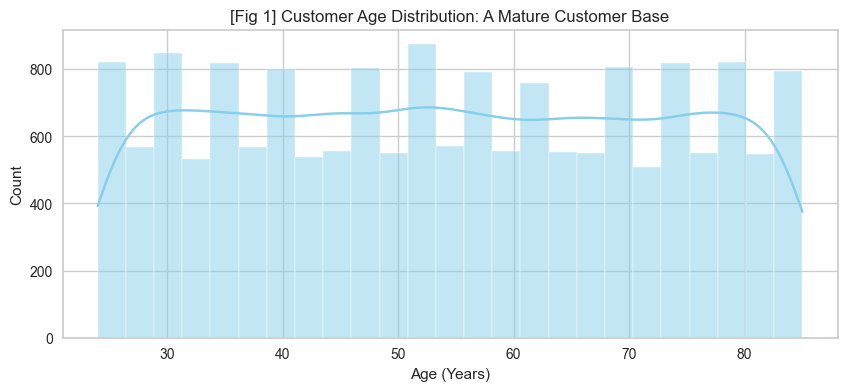

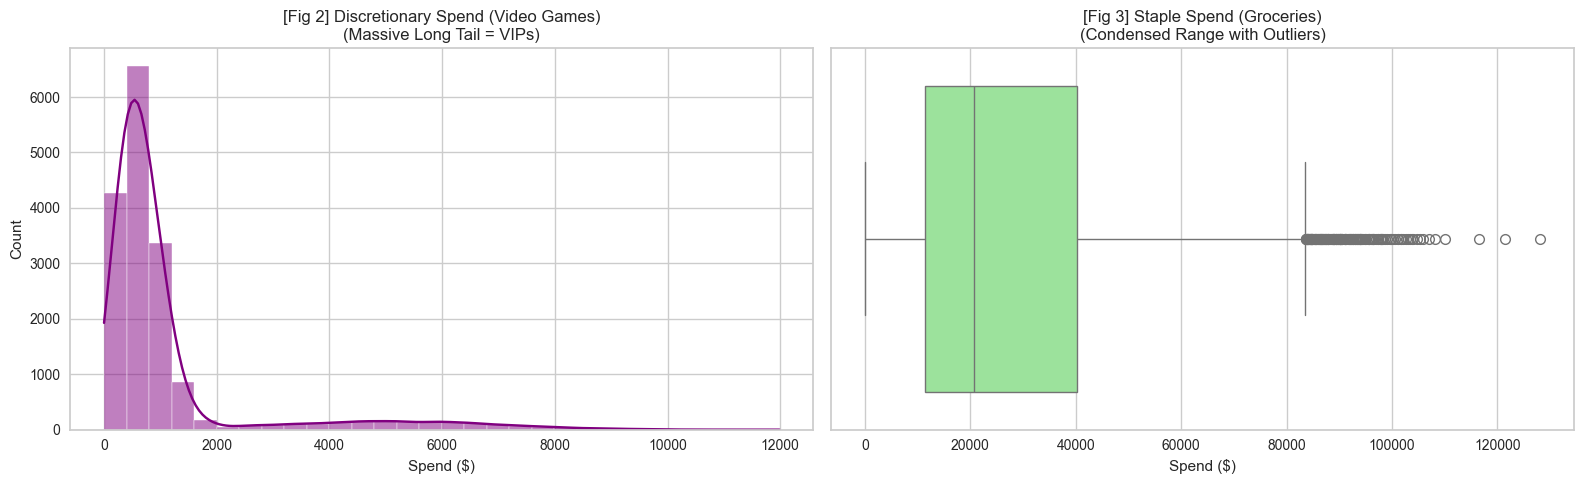

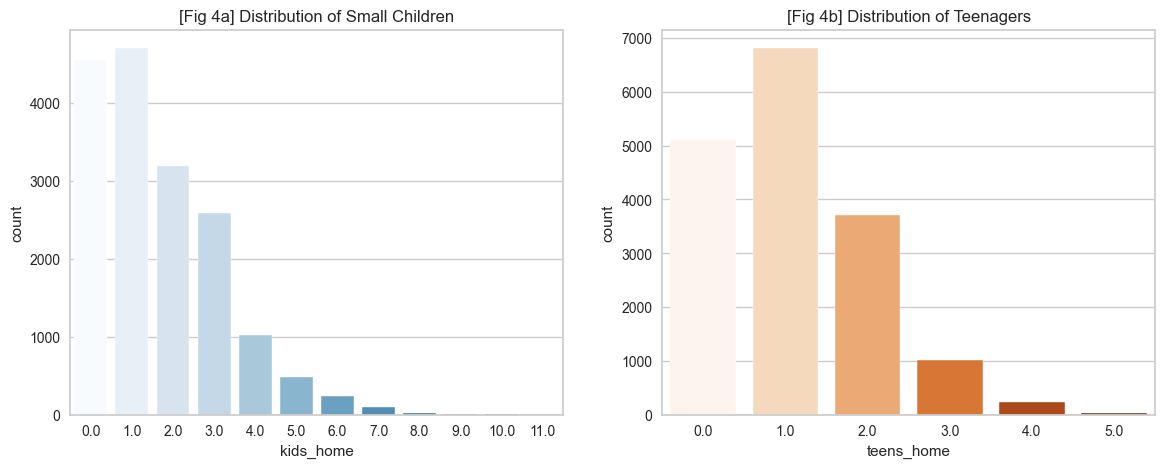

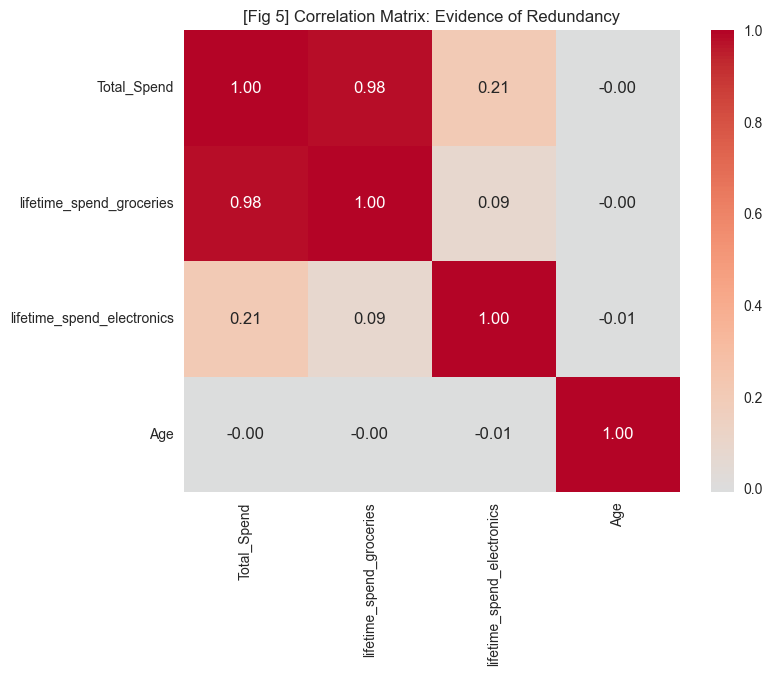

In [3]:
# 0. Temporary Setup
viz_data = data.copy()
if 'customer_birthdate' in viz_data.columns:
    viz_data['customer_birthdate'] = pd.to_datetime(viz_data['customer_birthdate'], errors='coerce')
    viz_data['Age'] = 2025 - viz_data['customer_birthdate'].dt.year

# [Fig 1] Demographics
plt.figure(figsize=(10, 4))
sns.histplot(viz_data['Age'].dropna(), kde=True, color='skyblue', bins=25)
plt.title('[Fig 1] Customer Age Distribution: A Mature Customer Base')
plt.xlabel('Age (Years)')
plt.show()

# [Fig 2 & 3] Financial Skewness (Independent Scales)
# We split them to avoid the "Squashing" effect
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# [Fig 2] The "Whale" Category (Video Games)
# Using Log scale on Y-axis helps visualize the tail better if needed,
# but here we stick to raw to show the magnitude.
sns.histplot(viz_data['lifetime_spend_videogames'], kde=True, ax=axes[0], color='purple', bins=30)
axes[0].set_title('[Fig 2] Discretionary Spend (Video Games)\n(Massive Long Tail = VIPs)')
axes[0].set_xlabel('Spend ($)')

# [Fig 3] The "Staple" Category (Groceries)
# We use a Boxplot here to show the IQR distribution clearly
sns.boxplot(x=viz_data['lifetime_spend_groceries'], ax=axes[1], color='lightgreen')
axes[1].set_title('[Fig 3] Staple Spend (Groceries)\n(Condensed Range with Outliers)')
axes[1].set_xlabel('Spend ($)')

plt.tight_layout()
plt.show()

# [Fig 4] Family Composition (Fixed Warnings)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x=viz_data['kids_home'], ax=axes[0], hue=viz_data['kids_home'], palette='Blues', legend=False)
axes[0].set_title('[Fig 4a] Distribution of Small Children')

sns.countplot(x=viz_data['teens_home'], ax=axes[1], hue=viz_data['teens_home'], palette='Oranges', legend=False)
axes[1].set_title('[Fig 4b] Distribution of Teenagers')
plt.show()

# [Fig 5] Correlation
spend_cols = [c for c in viz_data.columns if 'lifetime_spend_' in c]
viz_data['Total_Spend'] = viz_data[spend_cols].sum(axis=1)

corr_vars = ['Total_Spend', 'lifetime_spend_groceries', 'lifetime_spend_electronics', 'Age']

plt.figure(figsize=(8, 6))
corr_matrix = viz_data[corr_vars].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('[Fig 5] Correlation Matrix: Evidence of Redundancy')
plt.show()

### 4. Data Preprocessing & Transformation

**Objective:**
Convert the raw dataset into a clean, numerical matrix optimized for K-Means/K-Prototypes clustering.

**Summary of Transformations:**
* **Imputation:** Applied KNN ($k=5$) to metric features and Mode imputation to categorical features to resolve missingness.
* **Outlier Removal (Filtering):** Removed rows based on business logic limits (e.g., > 8 kids or > 6 store visits) to ensure "impossible" data doesn't skew the model.
* **Outlier Capping (Winsorization):** Applied to high-variance spending columns (Video Games, Electronics) to preserve "Whale" customers without distorting the scale.
* **Feature Engineering:** Created **7 new features** focusing on behavioral ratios (e.g., `Share_Tech_Gaming`) and aggregates (`Total_Spend`), replacing **20 raw columns** to reduce multicollinearity.
* **Final Dimensions:** The dataset moved from raw input to a final, lower-dimensional shape, fully Scaled via `RobustScaler`.

#### 4.1. Data Preparation & Classification
We categorize features into **Metric** (Numerical) and **Non-Metric** (Categorical) to apply the correct processing strategy (KNN vs Mode).

#### 4.2. Data Cleaning
We address the two main data quality issues identified in Section 3: Missing Values and Extreme Outliers.

##### 4.2.1 Missing Values
**Strategy: Hybrid Imputation**
* **Metrics (KNN):** We use **K-Nearest Neighbors ($k=5$)** to fill missing numerical values based on similarity.
* **Categoricals (Mode):** We use the Most Frequent Value (Mode) for non-numeric columns like `customer_gender` to avoid dropping potentially valuable rows.

##### 4.2.2 Detect and Remove Outliers
**Strategy: Filter & Cap**
1.  **Business Logic Filtering:** We remove "impossible" values (e.g., > 20 complaints) as noise.
2.  **Winsorization:** We **cap** extreme spending values at a calculated limit (e.g., 3.0x IQR). This keeps "Whale" customers in the dataset but brings their values within a mathematical range that `RobustScaler` can handle.

#### 4.3. Feature Engineering
**Strategy: Behavioral Ratios**
To solve the "Rich vs. Poor" clustering trap, we engineer features that describe *lifestyle* rather than just magnitude.
* **`Share_Tech_Gaming`**: Identifies tech enthusiasts regardless of total budget.
* **`Share_Fresh_Food`**: Identifies home cooks/families.
* **`Total_Spend`**: Aggregates all spending to create a single "Monetary Value" dimension.

#### 4.4. Correlations & Selection
**Strategy: Reducing Multicollinearity**
We compare the correlation matrices of the "Raw" vs. "Engineered" datasets.
* **4.4.1 Justification:** We demonstrate that raw spending columns (e.g., Groceries) are 98% correlated with Total Spend.
* **4.4.2 Execution:** We drop these redundant columns and the high-cardinality IDs, keeping only the **Shares** and **Total_Spend**.

#### 4.5. Scaling
**Strategy: Robust Scaler**
We apply **`RobustScaler`** (Median/IQR based) instead of Standard Scaler. This ensures that any remaining high-value customers do not "squash" the distribution of the rest of the dataset.

--- 4.2.1 Applying Imputation ---
Missing values imputed.

--- 4.2.2 Outlier Handling ---
Business Logic Filtering dropped 173 rows (1.02%).
Winsorization applied: 2611 values capped across 5 columns.

--- 4.3 Feature Engineering ---
Features Engineered. Total columns before selection: 32


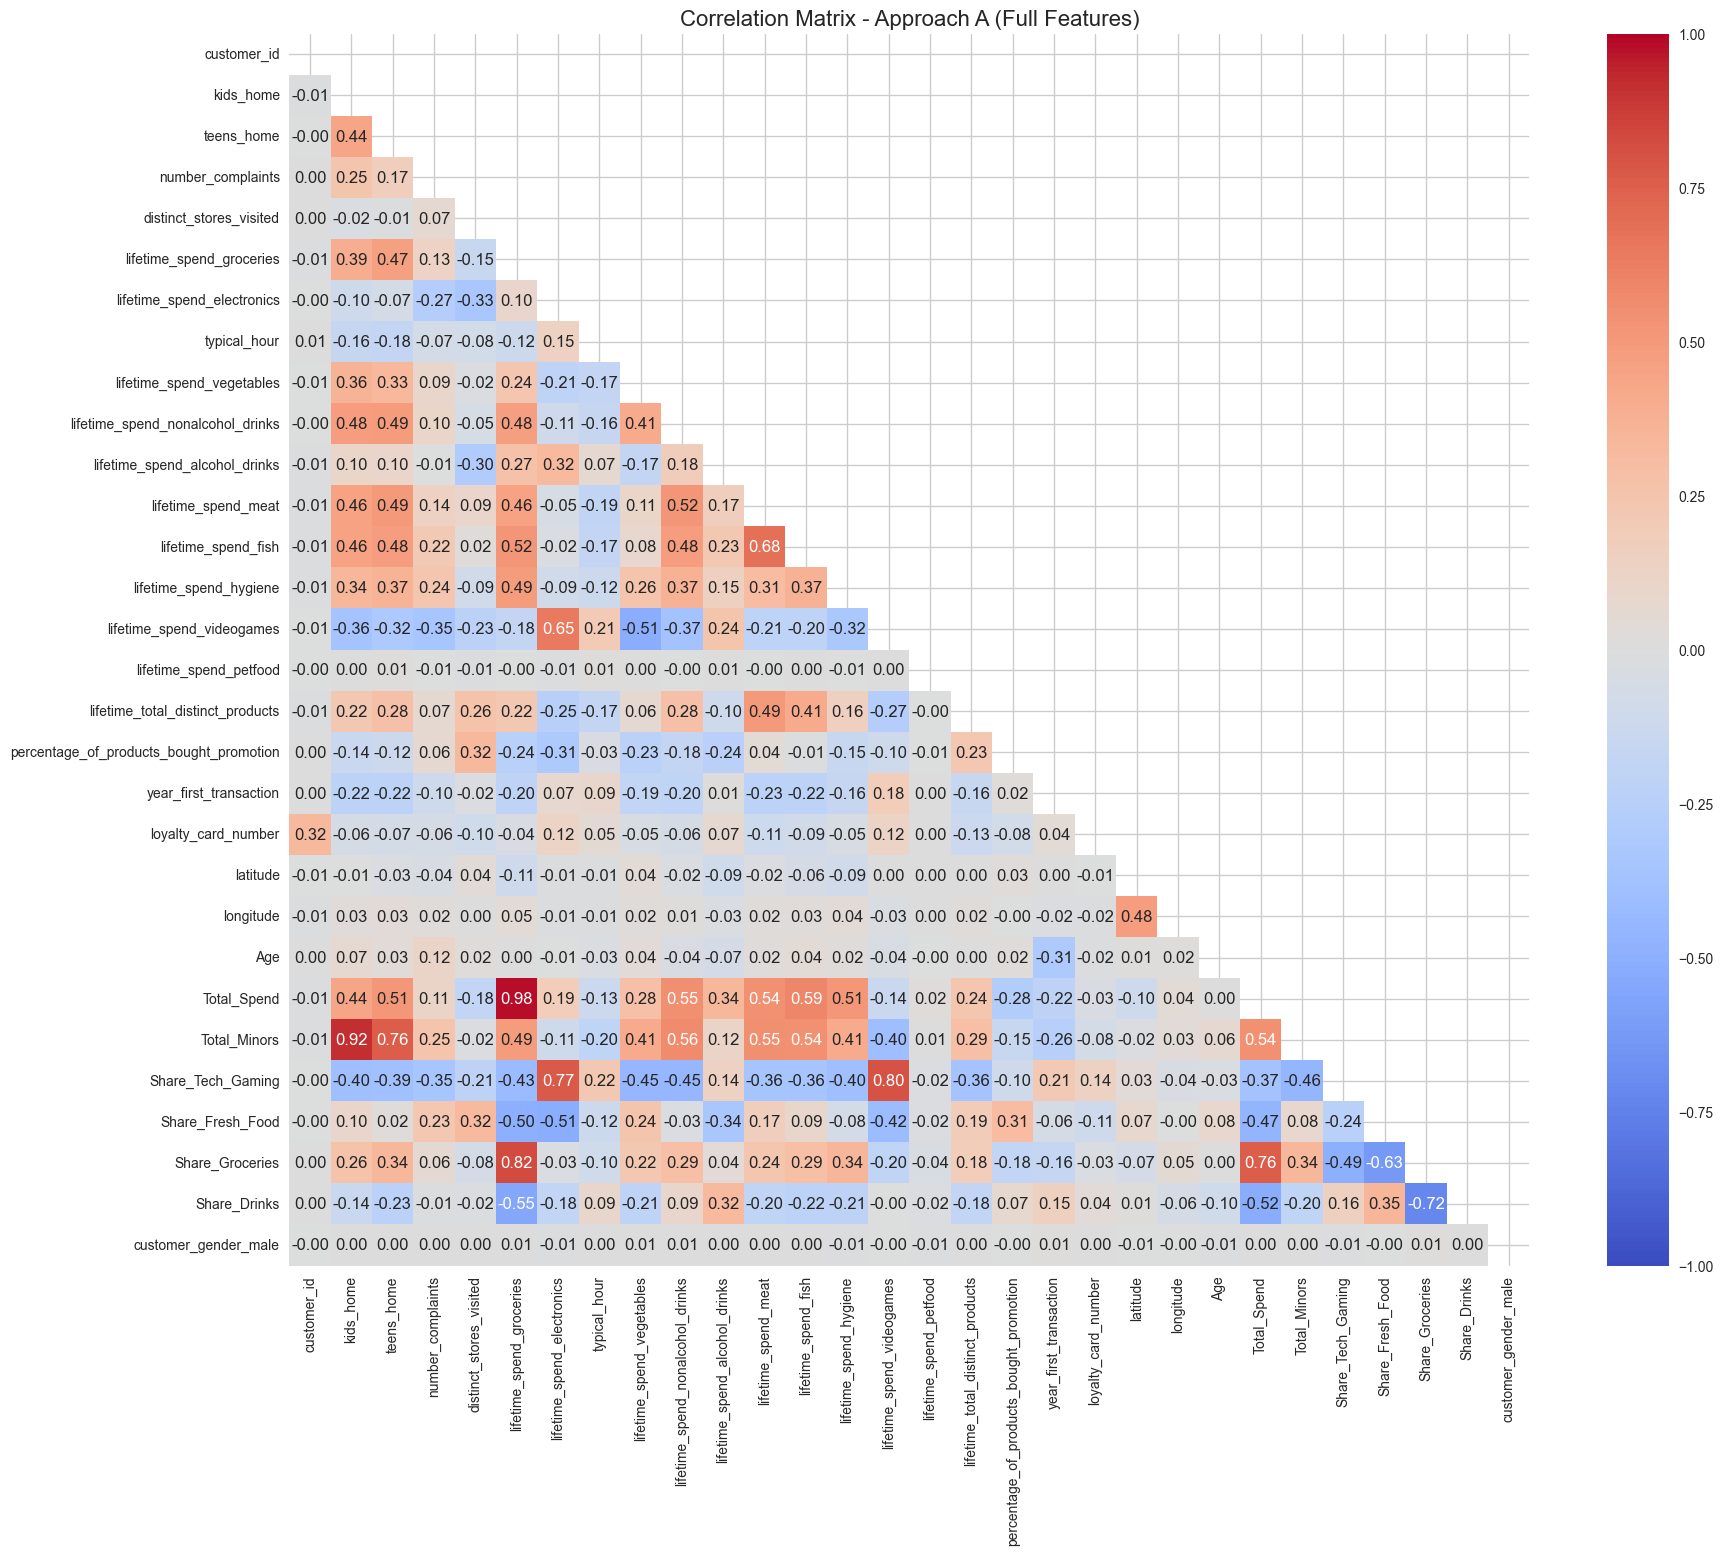

Highly Correlated Pairs (> 0.8):
Total_Spend <--> lifetime_spend_groceries: 0.98
Total_Minors <--> kids_home: 0.92
Share_Tech_Gaming <--> lifetime_spend_videogames: 0.80
Share_Groceries <--> lifetime_spend_groceries: 0.82
Dropped 22 redundant features.
Final Feature Set (10 columns):
['number_complaints', 'distinct_stores_visited', 'percentage_of_products_bought_promotion', 'Age', 'Total_Spend', 'Total_Minors', 'Share_Tech_Gaming', 'Share_Fresh_Food', 'Share_Groceries', 'Share_Drinks']


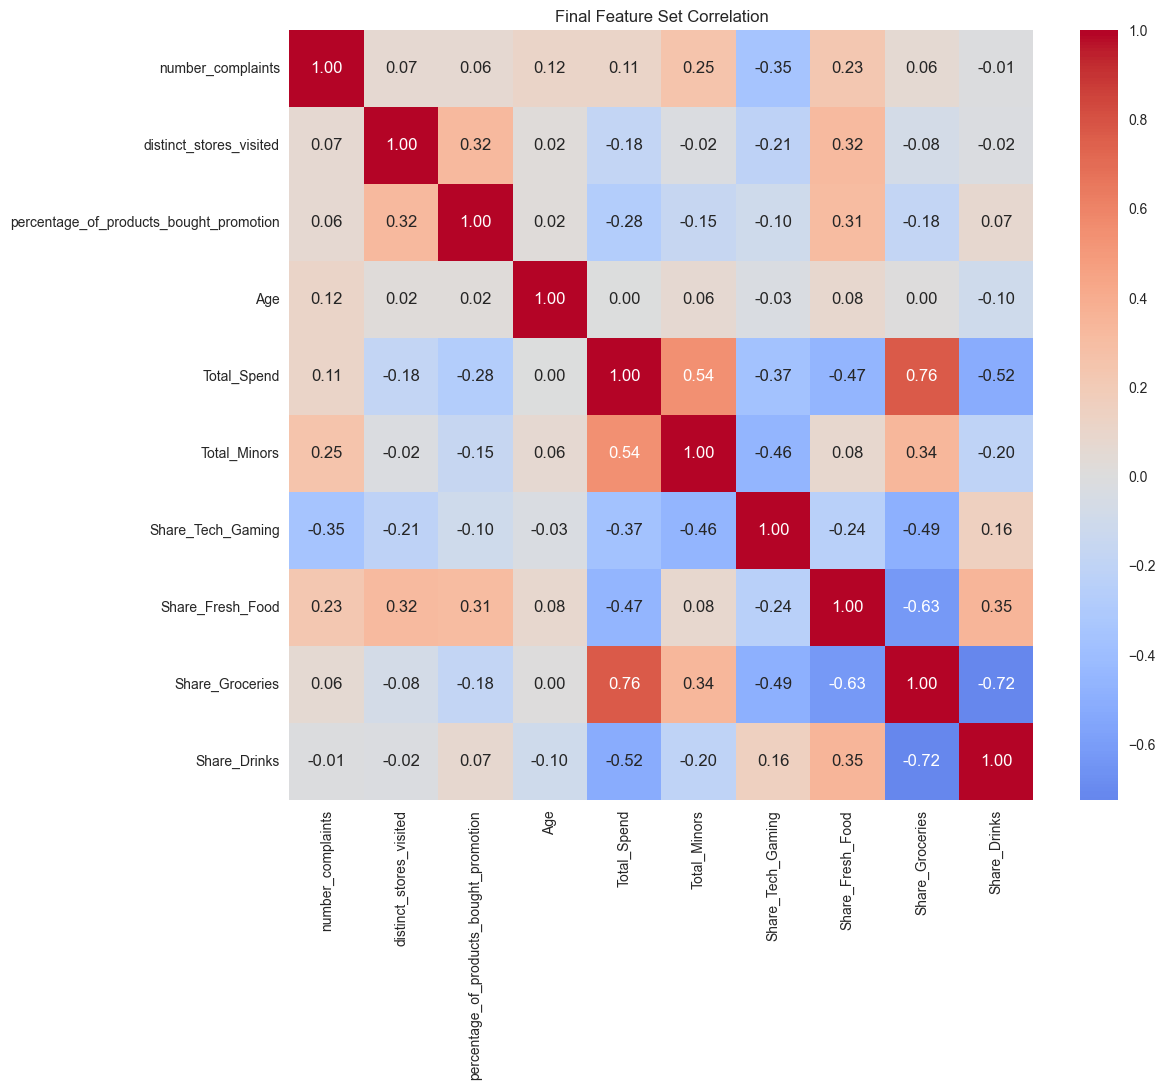


--- 4.5 SCALING ---


In [4]:
# 4.1. DATA PREPARATION & CLASSIFICATION
df_process = data.copy()
initial_shape = df_process.shape

# 1. Identifiers / Descriptors (Non-Metric)
non_metric_features = [
    'customer_name', 'customer_gender', 'customer_birthdate',
    'loyalty_card_number', 'latitude', 'longitude',
    'year_first_transaction', 'typical_hour'
]

# 2. Count Metrics (Integers) -> Handled via Logic Filters
count_features = [
    'kids_home', 'teens_home', 'number_complaints', 'distinct_stores_visited'
]

# 3. Continuous Metrics (Money) -> Handled via Capping
spending_features = [
    'lifetime_spend_groceries', 'lifetime_spend_electronics', 'lifetime_spend_vegetables',
    'lifetime_spend_nonalcohol_drinks', 'lifetime_spend_alcohol_drinks', 'lifetime_spend_meat',
    'lifetime_spend_fish', 'lifetime_spend_hygiene', 'lifetime_spend_videogames',
    'lifetime_spend_petfood', 'lifetime_total_distinct_products',
    'percentage_of_products_bought_promotion'
]

metric_features = count_features + spending_features

# Ensure types are numeric
for col in metric_features:
    df_process[col] = pd.to_numeric(df_process[col], errors='coerce')

# 4.2.1. MISSING VALUES (Hybrid Strategy)
print("--- 4.2.1 Applying Imputation ---")
# A. Metric -> KNN
imputer = KNNImputer(n_neighbors=5)
df_process[metric_features] = imputer.fit_transform(df_process[metric_features])

# B. Non-Metric -> Mode
for col in non_metric_features:
    if col in df_process.columns:
        mode_val = df_process[col].mode()[0]
        df_process[col] = df_process[col].fillna(mode_val)
print("Missing values imputed.")

# 4.2.2. OUTLIERS (Hybrid: Filter + Cap)
print("\n--- 4.2.2 Outlier Handling ---")

# A. Business Logic Filter
rows_before_filter = len(df_process)
df_process = df_process[
    (df_process['kids_home'] <= 8) &
    (df_process['number_complaints'] <= 5) &
    (df_process['teens_home'] <= 4) &
    (df_process['distinct_stores_visited'] <= 6)
].copy()
rows_dropped = rows_before_filter - len(df_process)
print(f"Business Logic Filtering dropped {rows_dropped} rows ({(rows_dropped/initial_shape[0])*100:.2f}%).")

# B. Winsorization
def cap_outliers(df, threshold_dict):
    df_clean = df.copy()
    caps_count = 0
    for col, thresh in threshold_dict.items():
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        upper_limit = Q3 + thresh * IQR

        mask = df_clean[col] > upper_limit
        if mask.sum() > 0:
            df_clean.loc[mask, col] = upper_limit
            caps_count += mask.sum()
    return df_clean, caps_count

capping_rules = {
    'lifetime_spend_videogames': 3.0,
    'lifetime_spend_electronics': 3.0,
    'distinct_stores_visited': 3.0,
    'lifetime_spend_groceries': 1.5,
    'lifetime_spend_meat': 1.5
}

df_capped, total_caps = cap_outliers(df_process, capping_rules)
print(f"Winsorization applied: {total_caps} values capped across {len(capping_rules)} columns.")

# 4.3. FEATURE ENGINEERING & ENCODING
print("\n--- 4.3 Feature Engineering ---")

current_year = 2025
# 1. Base Engineering
if 'customer_birthdate' in df_capped.columns:
    df_capped['customer_birthdate'] = pd.to_datetime(df_capped['customer_birthdate'], errors='coerce')
    df_capped['Age'] = current_year - df_capped['customer_birthdate'].dt.year

spend_cols = [col for col in df_capped.columns if 'lifetime_spend_' in col]
df_capped['Total_Spend'] = df_capped[spend_cols].sum(axis=1)
df_capped['Total_Minors'] = df_capped['kids_home'] + df_capped['teens_home']

# 2. Ratios
total_safe = df_capped['Total_Spend'] + 1e-6
df_capped['Share_Tech_Gaming'] = (df_capped['lifetime_spend_electronics'] + df_capped['lifetime_spend_videogames']) / total_safe
df_capped['Share_Fresh_Food'] = (df_capped['lifetime_spend_vegetables'] + df_capped['lifetime_spend_meat'] + df_capped['lifetime_spend_fish']) / total_safe
df_capped['Share_Groceries'] = df_capped['lifetime_spend_groceries'] / total_safe
df_capped['Share_Drinks'] = (df_capped['lifetime_spend_alcohol_drinks'] + df_capped['lifetime_spend_nonalcohol_drinks']) / total_safe

# 3. Encoding Gender
if 'customer_gender' in df_capped.columns:
    df_capped = pd.get_dummies(df_capped, columns=['customer_gender'], drop_first=True, dtype=int)

new_cols_count = len(df_capped.columns) - len(df_process.columns)
print(f"Features Engineered. Total columns before selection: {len(df_capped.columns)}")

# 4.4.1 Correlation Matrix: Raw Regional Data

def plot_correlation_heatmap(df, title):
    # Select only numeric columns for correlation
    numeric_df = df.select_dtypes(include=[np.number])

    # Calculate correlation matrix
    corr_matrix = numeric_df.corr()

    # Plot
    plt.figure(figsize=(20, 16))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # Hide upper triangle
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, center=0)
    plt.title(title, fontsize=16)
    plt.show()

    return corr_matrix

# We check 'data_mode_final' (Approach A) as our representative sample
corr_matrix_A = plot_correlation_heatmap(df_capped, "Correlation Matrix - Approach A (Full Features)")

high_corr_pairs = []
for i in range(len(corr_matrix_A.columns)):
    for j in range(i):
        if abs(corr_matrix_A.iloc[i, j]) > 0.8:
            col1 = corr_matrix_A.columns[i]
            col2 = corr_matrix_A.columns[j]
            high_corr_pairs.append((col1, col2, corr_matrix_A.iloc[i, j]))

print("Highly Correlated Pairs (> 0.8):")
for pair in high_corr_pairs:
    print(f"{pair[0]} <--> {pair[1]}: {pair[2]:.2f}")

# 4.4. Iden

# 1. Drop Raw Spending (Because we have 'Total_Spend' + 'Shares')
# The 0.98 correlation confirms these are 100% redundant
raw_spend_cols = [
    'lifetime_spend_groceries', 'lifetime_spend_electronics',
    'lifetime_spend_vegetables', 'lifetime_spend_nonalcohol_drinks',
    'lifetime_spend_alcohol_drinks', 'lifetime_spend_meat',
    'lifetime_spend_fish', 'lifetime_spend_hygiene',
    'lifetime_spend_videogames', 'lifetime_spend_petfood',
    'lifetime_total_distinct_products' # Correlated with distinct_stores
]

# 2. Drop Components of Aggregates (Because we have 'Total_Minors')
# The 0.90 correlation confirms redundancy
family_cols = ['kids_home', 'teens_home']

# 3. Drop High Correlation duplicates
# Avg_Spend is 0.88 correlated with Total_Spend. We drop it to balance the weights.
behavior_cols = ['Avg_Spend_Per_Visit']
other_cols = [
    'customer_name', 'latitude', 'longitude', 'customer_birthdate',
    'customer_id', 'loyalty_card_number', 'year_first_transaction', 'typical_hour', 'customer_gender_male']

# Execute Drop
cols_to_drop = raw_spend_cols + family_cols + behavior_cols + other_cols
# Only drop columns that actually exist in the dataframe
cols_to_drop = [c for c in cols_to_drop if c in df_capped.columns]

df_capped.drop(columns=cols_to_drop, inplace=True)

print(f"Dropped {len(cols_to_drop)} redundant features.")
print(f"Final Feature Set ({df_capped.shape[1]} columns):")
print(df_capped.columns.tolist())

plt.figure(figsize=(12, 10))
sns.heatmap(df_capped.select_dtypes(include='number').corr(), annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Final Feature Set Correlation")
plt.show()

# 4.5 SCALING
print("\n--- 4.5 SCALING ---")
scaler = RobustScaler()
data_scaled_array = scaler.fit_transform(df_capped)
df_scaled = pd.DataFrame(data_scaled_array, columns=df_capped.columns, index=df_capped.index)

In [5]:
# --- UPDATE FEATURE LISTS FOR CLUSTERING ---
# updated metric_features to match exactly what is in df_scaled
metric_features = df_scaled.columns.tolist()

print("Features used for Clustering:", metric_features)
print(f"Data Shape: {df_scaled.shape}")

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA

# --- 1. K-MEANS INERTIA PLOT (From Lab 03b) ---
def plot_inertia(df, feats, max_k=10):
    range_clusters = range(1, max_k+1)
    inertia = []
    for n_clus in range_clusters:
        # Teacher used k-means++ and n_init=15
        kmclust = KMeans(n_clusters=n_clus, init='k-means++', n_init=15, random_state=1)
        kmclust.fit(df[feats])
        inertia.append(kmclust.inertia_)

    plt.figure(figsize=(9,5))
    plt.plot(range_clusters, inertia, marker='o')
    plt.ylabel("Inertia: SSw")
    plt.xlabel("Number of clusters")
    plt.xticks(range_clusters)
    plt.title("Inertia plot over clusters", size=15)
    plt.grid(True)
    plt.show()

# --- 2. HIERARCHICAL R2 PLOT (From Lab 03a) ---
def get_r2_hc(df, link_method, max_nclus, min_nclus=1, dist="euclidean"):
    def get_ss(df):
        return np.sum(df.var() * (df.count() - 1))

    sst = get_ss(df)
    r2 = []

    for i in range(min_nclus, max_nclus+1):
        cluster = AgglomerativeClustering(n_clusters=i, metric=dist, linkage=link_method)
        hclabels = cluster.fit_predict(df)

        df_concat = pd.concat((df, pd.Series(hclabels, name='labels', index=df.index)), axis=1)
        ssw_labels = df_concat.groupby(by='labels').apply(get_ss)
        ssb = sst - np.sum(ssw_labels)
        r2.append(ssb / sst)

    return np.array(r2)

def plot_r2_linkage(df, max_nclus):
    hc_methods = ["ward", "complete", "average", "single"]

    r2_hc_methods = np.vstack(
        [get_r2_hc(df=df, link_method=link, max_nclus=max_nclus) for link in hc_methods]
    ).T

    r2_df = pd.DataFrame(r2_hc_methods, index=range(1, max_nclus + 1), columns=hc_methods)

    plt.figure(figsize=(11,5))
    sns.lineplot(data=r2_df, linewidth=2.5, markers=["o"]*4)
    plt.title("R2 plot for various hierarchical methods", fontsize=21)
    plt.xlabel("Number of clusters", fontsize=13)
    plt.ylabel("R2 metric", fontsize=13)
    plt.grid(True)
    plt.show()

# --- 3. CLUSTER PROFILING TABLE (From Lab 03a) ---
def get_mean_bylabel(df, feats, label_name):
    # Group by the cluster label and calculate the mean of features
    return df[feats+[label_name]].groupby(label_name).mean()

# --- 4. PCA VISUALIZATION (Standard 2D Projection) ---
def plot_clusters_pca(df_scaled, labels, title="Cluster Visualization"):
    pca = PCA(n_components=2)
    pca_data = pca.fit_transform(df_scaled)

    plt.figure(figsize=(10, 7))
    sns.scatterplot(x=pca_data[:,0], y=pca_data[:,1], hue=labels, palette='viridis', s=50)
    plt.title(f'{title} (PCA Projection)')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend(title='Cluster')
    plt.show()

Features used for Clustering: ['number_complaints', 'distinct_stores_visited', 'percentage_of_products_bought_promotion', 'Age', 'Total_Spend', 'Total_Minors', 'Share_Tech_Gaming', 'Share_Fresh_Food', 'Share_Groceries', 'Share_Drinks']
Data Shape: (16805, 10)


### 5.1.1 K-Means Clustering

**Objective:**
Apply K-Means clustering to partition the customer base into distinct groups based on their spending behavior and demographics.

**Methodology:**
1.  **Elbow Method:** We will calculate the Within-Cluster Sum of Squares (Inertia) for $K=2$ to $K=10$ to find the optimal number of clusters.
2.  **Silhouette Score:** We will verify the quality of the clusters (higher is better).
3.  **Visualisation:** We will project the clusters onto 2D space (using the top 2 features or PCA) to inspect separation.

--- Step 1: Elbow Method (Inertia Plot) ---


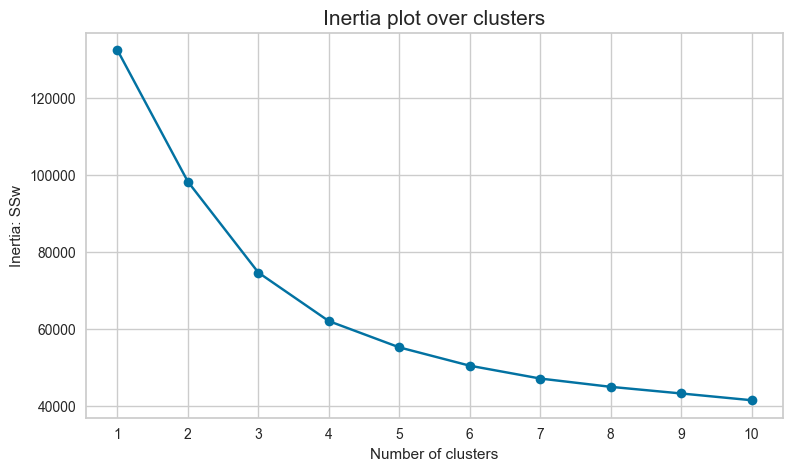


--- Step 2: Silhouette Score Analysis ---
K=2: Silhouette Score = 0.3933
K=3: Silhouette Score = 0.3246
K=4: Silhouette Score = 0.3098
K=5: Silhouette Score = 0.2451
K=6: Silhouette Score = 0.2301
K=7: Silhouette Score = 0.2110
K=8: Silhouette Score = 0.2020
K=9: Silhouette Score = 0.1939
K=10: Silhouette Score = 0.1682


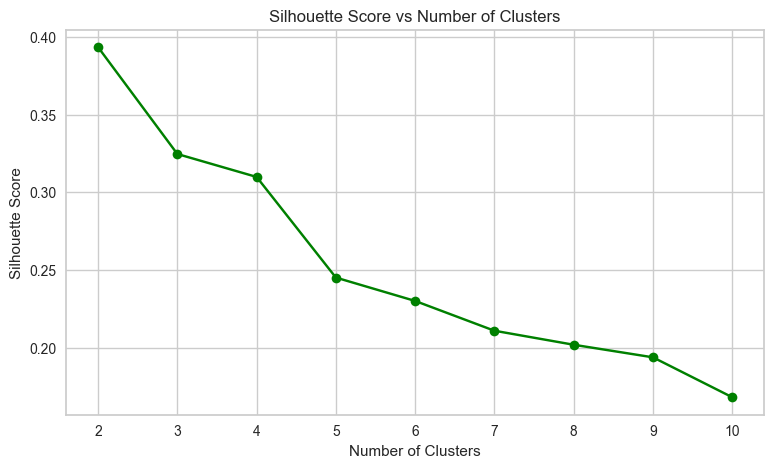


--- Step 3: Fit K-Means with K=4 ---
K-Means clustering completed with K=4
Cluster distribution:
Cluster_KMeans
0    9645
1    1950
2    1865
3    3345
Name: count, dtype: int64

--- Step 4: PCA Visualization ---


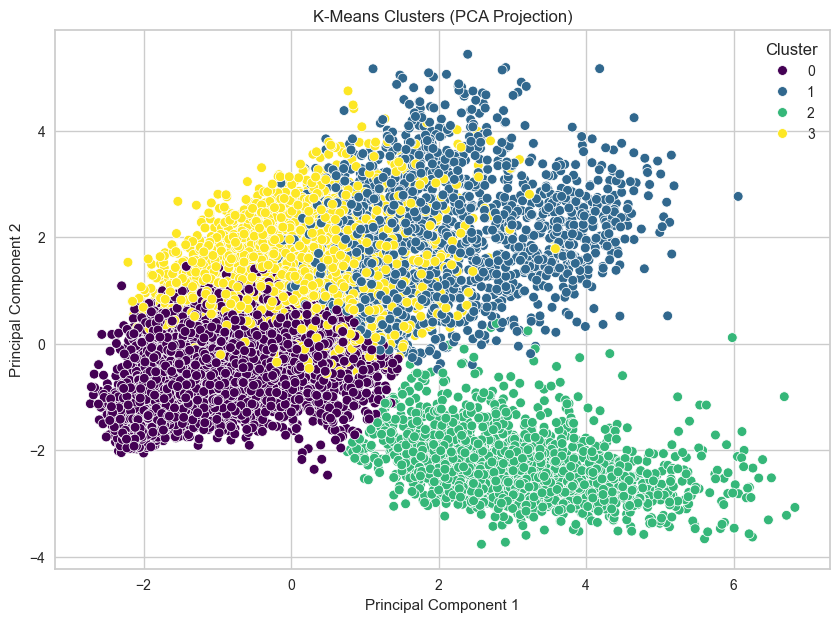


--- Step 5: Cluster Profiles (Original/Unscaled Values) ---


,number_complaints,distinct_stores_visited,percentage_of_products_bought_promotion,Age,Total_Spend,Total_Minors,Share_Tech_Gaming,Share_Fresh_Food,Share_Groceries,Share_Drinks
Cluster_KMeans,,,,,,,,,,
0,1.22,1.61,0.37,54.66,56339.17,3.64,0.06,0.16,0.65,0.09
1,1.41,1.64,0.48,52.97,18802.38,2.19,0.11,0.30,0.27,0.23
2,0.21,1.01,0.30,54.20,31995.56,0.44,0.33,0.08,0.45,0.11
3,1.08,3.52,0.64,54.69,26525.86,1.68,0.09,0.23,0.50,0.11



--- Step 5b: Cluster Profiles (Scaled Values - for reference) ---


,number_complaints,distinct_stores_visited,percentage_of_products_bought_promotion,Age,Total_Spend,Total_Minors,Share_Tech_Gaming,Share_Fresh_Food,Share_Groceries,Share_Drinks
Cluster_KMeans,,,,,,,,,,
0,0.110,-0.391,-0.104,0.021,0.510,0.546,-0.135,-0.102,0.326,-0.206
1,0.207,-0.355,0.242,-0.033,-0.475,0.063,0.675,1.100,-1.509,2.652
2,-0.394,-0.993,-0.355,0.006,-0.129,-0.519,3.994,-0.853,-0.648,0.248
3,0.040,1.522,0.748,0.022,-0.273,-0.106,0.317,0.543,-0.399,0.250


In [6]:
# --- 5.1.1 K-MEANS CLUSTERING ---
from sklearn.metrics import silhouette_score

# 1. Elbow Method: Plot Inertia to find optimal K
print("--- Step 1: Elbow Method (Inertia Plot) ---")
plot_inertia(df_scaled, metric_features, max_k=10)

# 2. Silhouette Analysis: Verify cluster quality
print("\n--- Step 2: Silhouette Score Analysis ---")
range_clusters = range(2, 11)
silhouette_scores = []

for k in range_clusters:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=15, random_state=42)
    labels = kmeans.fit_predict(df_scaled[metric_features])
    score = silhouette_score(df_scaled[metric_features], labels)
    silhouette_scores.append(score)
    print(f"K={k}: Silhouette Score = {score:.4f}")

plt.figure(figsize=(9, 5))
plt.plot(range_clusters, silhouette_scores, marker='o', color='green')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.xticks(range_clusters)
plt.grid(True)
plt.show()

# 3. Fit Final K-Means with Optimal K (based on elbow/silhouette)
OPTIMAL_K_KMEANS = 4  # <-- Adjust based on the plots above!
print(f"\n--- Step 3: Fit K-Means with K={OPTIMAL_K_KMEANS} ---")

kmeans_final = KMeans(n_clusters=OPTIMAL_K_KMEANS, init='k-means++', n_init=15, random_state=42)
df_scaled['Cluster_KMeans'] = kmeans_final.fit_predict(df_scaled[metric_features])

print(f"K-Means clustering completed with K={OPTIMAL_K_KMEANS}")
print(f"Cluster distribution:\n{df_scaled['Cluster_KMeans'].value_counts().sort_index()}")

# 4. Visualize Clusters using PCA
print("\n--- Step 4: PCA Visualization ---")
plot_clusters_pca(df_scaled[metric_features], df_scaled['Cluster_KMeans'], title="K-Means Clusters")

# 5. Cluster Profiling: Mean values per cluster
# Use df_capped (unscaled but same rows as df_scaled) for interpretable profiles
df_capped['Cluster_KMeans'] = df_scaled['Cluster_KMeans'].values

# Also save to data using index alignment (handles row count mismatch)
data.loc[df_scaled.index, 'Cluster_KMeans'] = df_scaled['Cluster_KMeans'].values

print("\n--- Step 5: Cluster Profiles (Original/Unscaled Values) ---")
cluster_profiles_kmeans = get_mean_bylabel(df_capped, metric_features, 'Cluster_KMeans')
display(cluster_profiles_kmeans.style.background_gradient(cmap='RdYlGn', axis=0).format("{:.2f}"))

print("\n--- Step 5b: Cluster Profiles (Scaled Values - for reference) ---")
cluster_profiles_kmeans_scaled = get_mean_bylabel(df_scaled, metric_features, 'Cluster_KMeans')
display(cluster_profiles_kmeans_scaled.style.background_gradient(cmap='RdYlGn', axis=0).format("{:.3f}"))

### 5.1.1b K-Means Clustering by Perspectives

**Objective:**
Instead of clustering on all features simultaneously, we define **perspectives** (meaningful subsets of features) and cluster separately on each perspective. This approach allows us to understand customer segments from different viewpoints.

**Perspectives Defined:**
1. **Behavioral Perspective:** Features related to customer engagement and shopping behavior
   - `distinct_stores_visited`, `number_complaints`, `percentage_of_products_bought_promotion`
   
2. **Spending Preference Perspective:** Features related to *what* customers buy (wallet share ratios)
   - `Share_Tech_Gaming`, `Share_Fresh_Food`, `Share_Groceries`, `Share_Drinks`

**Methodology:**
1. Define the feature subsets for each perspective
2. Apply K-Means clustering independently to each perspective
3. Create a contingency table to see how clusters overlap
4. Merge perspectives to create combined customer segments

CLUSTERING BY PERSPECTIVES

--- Step 1: Define Perspectives ---
Behavioral Perspective: ['distinct_stores_visited', 'number_complaints', 'percentage_of_products_bought_promotion']
Preference Perspective: ['Share_Tech_Gaming', 'Share_Fresh_Food', 'Share_Groceries', 'Share_Drinks']

--- Step 2: Elbow Method for Each Perspective ---


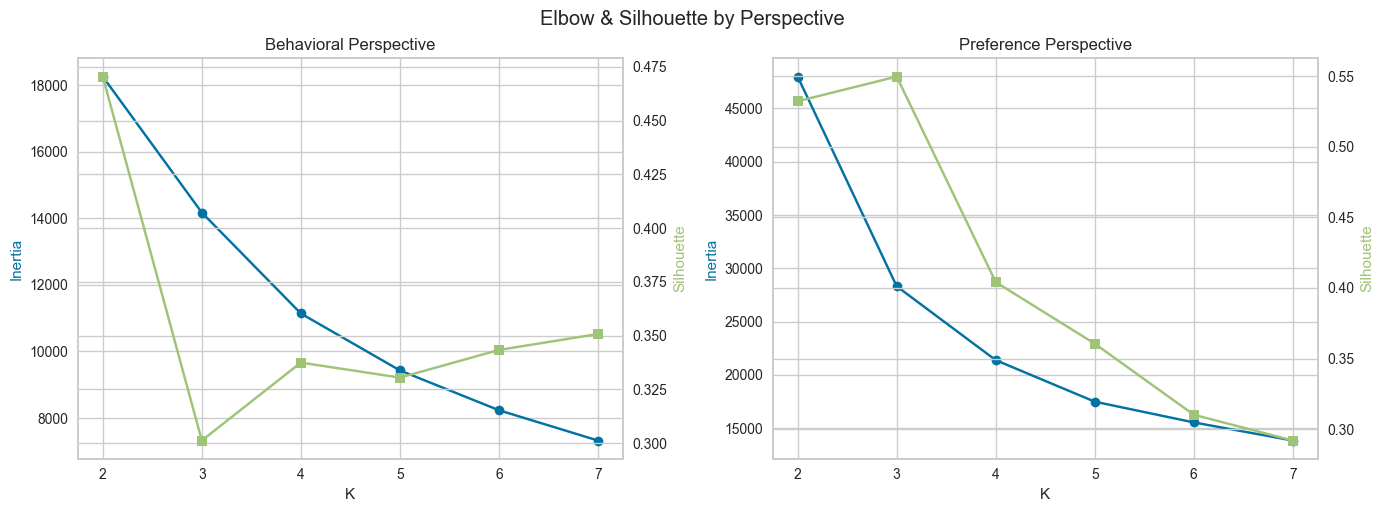


Silhouette Scores:
Behavioral: {2: '0.471', 3: '0.301', 4: '0.337', 5: '0.330', 6: '0.343', 7: '0.351'}
Preference: {2: '0.532', 3: '0.550', 4: '0.404', 5: '0.360', 6: '0.310', 7: '0.292'}

--- Step 3: Apply K-Means to Each Perspective ---
Behavioral clusters (K=3):
0    7586
1    3932
2    5287
Name: count, dtype: int64

Preference clusters (K=3):
0    12266
1     1832
2     2707
Name: count, dtype: int64

--- Step 4: Contingency Table (Behavioral vs Preference) ---

Rows = Preference Clusters, Columns = Behavioral Clusters


Cluster_Behavioral,0,1,2
Cluster_Preference,,,
0,5360,3054,3852
1,1443,23,366
2,783,855,1069


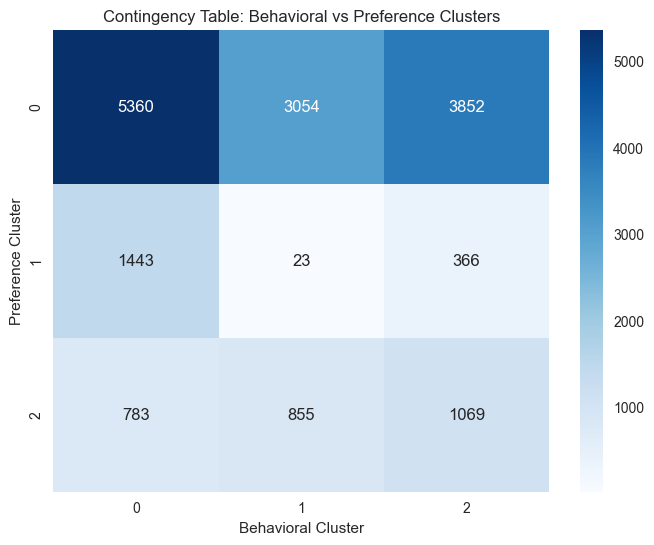


--- Step 5: Create Combined Segments ---
Combined Segment Distribution:
Cluster_Combined
B0_P0    5360
B0_P1    1443
B0_P2     783
B1_P0    3054
B1_P1      23
B1_P2     855
B2_P0    3852
B2_P1     366
B2_P2    1069
Name: count, dtype: int64


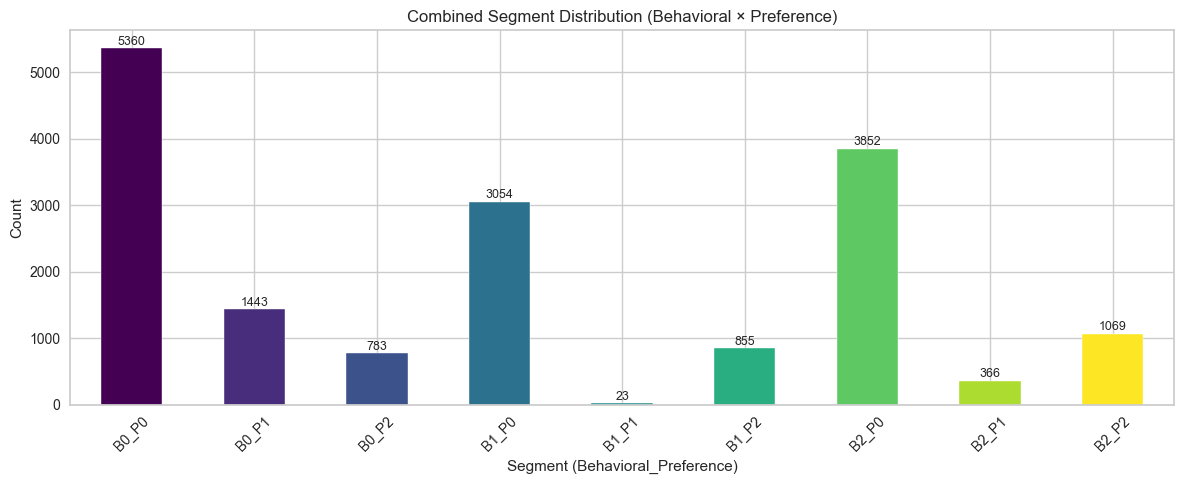


--- Step 6: Cluster Profiles by Perspective ---

[A] BEHAVIORAL PERSPECTIVE PROFILES (Unscaled):


,distinct_stores_visited,number_complaints,percentage_of_products_bought_promotion
Cluster_Behavioral,,,
0,1.36,0.97,0.25
1,3.63,1.13,0.56
2,1.48,1.28,0.60



[B] PREFERENCE PERSPECTIVE PROFILES (Unscaled):


,Share_Tech_Gaming,Share_Fresh_Food,Share_Groceries,Share_Drinks
Cluster_Preference,,,,
0,0.067,0.173,0.630,0.088
1,0.328,0.078,0.444,0.108
2,0.114,0.298,0.293,0.208



--- Step 7: PCA Visualization by Perspective ---


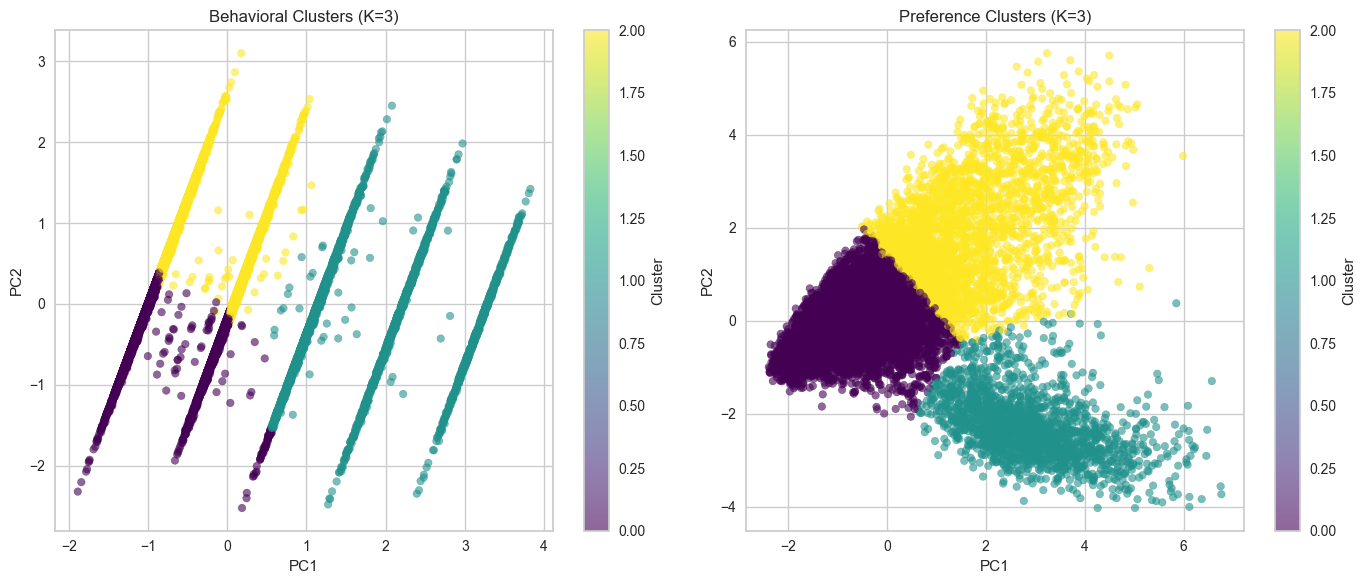


✓ Clustering by perspectives completed!
  - Behavioral perspective: 3 clusters
  - Preference perspective: 3 clusters
  - Combined segments: 9 unique combinations


In [7]:
# --- 5.1.1b K-MEANS CLUSTERING BY PERSPECTIVES ---

print("=" * 60)
print("CLUSTERING BY PERSPECTIVES")
print("=" * 60)

# ============================================================
# STEP 1: DEFINE PERSPECTIVES
# ============================================================
print("\n--- Step 1: Define Perspectives ---")

# Perspective 1: Behavioral (How customers shop)
behavioral_features = [
    'distinct_stores_visited',
    'number_complaints', 
    'percentage_of_products_bought_promotion'
]

# Perspective 2: Spending Preferences (What customers buy - wallet share)
preference_features = [
    'Share_Tech_Gaming',
    'Share_Fresh_Food', 
    'Share_Groceries',
    'Share_Drinks'
]

print(f"Behavioral Perspective: {behavioral_features}")
print(f"Preference Perspective: {preference_features}")

# Create perspective dataframes (scaled)
df_behavioral = df_scaled[behavioral_features].copy()
df_preference = df_scaled[preference_features].copy()

# ============================================================
# STEP 2: FIND OPTIMAL K FOR EACH PERSPECTIVE
# ============================================================
print("\n--- Step 2: Elbow Method for Each Perspective ---")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Behavioral perspective
inertias_beh = []
sil_beh = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, init='k-means++', n_init=15, random_state=42)
    labels = km.fit_predict(df_behavioral)
    inertias_beh.append(km.inertia_)
    sil_beh.append(silhouette_score(df_behavioral, labels))

axes[0].plot(range(2, 8), inertias_beh, 'b-o', label='Inertia')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia', color='b')
ax2 = axes[0].twinx()
ax2.plot(range(2, 8), sil_beh, 'g-s', label='Silhouette')
ax2.set_ylabel('Silhouette', color='g')
axes[0].set_title('Behavioral Perspective')
axes[0].grid(True)

# Preference perspective  
inertias_pref = []
sil_pref = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, init='k-means++', n_init=15, random_state=42)
    labels = km.fit_predict(df_preference)
    inertias_pref.append(km.inertia_)
    sil_pref.append(silhouette_score(df_preference, labels))

axes[1].plot(range(2, 8), inertias_pref, 'b-o', label='Inertia')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Inertia', color='b')
ax3 = axes[1].twinx()
ax3.plot(range(2, 8), sil_pref, 'g-s', label='Silhouette')
ax3.set_ylabel('Silhouette', color='g')
axes[1].set_title('Preference Perspective')
axes[1].grid(True)

plt.tight_layout()
plt.suptitle('Elbow & Silhouette by Perspective', y=1.02)
plt.show()

# Print silhouette scores
print("\nSilhouette Scores:")
print("Behavioral:", {k: f"{s:.3f}" for k, s in zip(range(2,8), sil_beh)})
print("Preference:", {k: f"{s:.3f}" for k, s in zip(range(2,8), sil_pref)})

# ============================================================
# STEP 3: APPLY K-MEANS TO EACH PERSPECTIVE
# ============================================================
print("\n--- Step 3: Apply K-Means to Each Perspective ---")

# Optimal K for each perspective (adjust based on plots!)
K_BEHAVIORAL = 3  # <-- Adjust based on elbow/silhouette
K_PREFERENCE = 3  # <-- Adjust based on elbow/silhouette

# Fit Behavioral clusters
kmeans_behavioral = KMeans(n_clusters=K_BEHAVIORAL, init='k-means++', n_init=15, random_state=42)
behavioral_labels = kmeans_behavioral.fit_predict(df_behavioral)
df_scaled['Cluster_Behavioral'] = behavioral_labels

print(f"Behavioral clusters (K={K_BEHAVIORAL}):")
print(pd.Series(behavioral_labels).value_counts().sort_index())

# Fit Preference clusters
kmeans_preference = KMeans(n_clusters=K_PREFERENCE, init='k-means++', n_init=15, random_state=42)
preference_labels = kmeans_preference.fit_predict(df_preference)
df_scaled['Cluster_Preference'] = preference_labels

print(f"\nPreference clusters (K={K_PREFERENCE}):")
print(pd.Series(preference_labels).value_counts().sort_index())

# ============================================================
# STEP 4: CONTINGENCY TABLE (Cross-tabulation)
# ============================================================
print("\n--- Step 4: Contingency Table (Behavioral vs Preference) ---")

def make_contingency_table(df, label1, label2):
    """Create a contingency table showing cluster overlap"""
    df_ = df.groupby([label1, label2]).size().to_frame('count').reset_index()
    df_ = df_.pivot(index=label2, columns=label1, values='count').fillna(0).astype(int)
    return df_

contingency = make_contingency_table(df_scaled, 'Cluster_Behavioral', 'Cluster_Preference')
print("\nRows = Preference Clusters, Columns = Behavioral Clusters")
display(contingency.style.background_gradient(cmap='Blues'))

# Heatmap visualization
plt.figure(figsize=(8, 6))
sns.heatmap(contingency, annot=True, fmt='d', cmap='Blues')
plt.title('Contingency Table: Behavioral vs Preference Clusters')
plt.xlabel('Behavioral Cluster')
plt.ylabel('Preference Cluster')
plt.show()

# ============================================================
# STEP 5: MERGE PERSPECTIVES INTO COMBINED SEGMENTS
# ============================================================
print("\n--- Step 5: Create Combined Segments ---")

# Create combined label (tuple of both perspectives)
df_scaled['Cluster_Combined'] = df_scaled.apply(
    lambda row: f"B{int(row['Cluster_Behavioral'])}_P{int(row['Cluster_Preference'])}", axis=1
)

# Show distribution of combined segments
combined_dist = df_scaled['Cluster_Combined'].value_counts().sort_index()
print("Combined Segment Distribution:")
print(combined_dist)

# Visualize combined segments
plt.figure(figsize=(12, 5))
combined_dist.plot(kind='bar', color=plt.cm.viridis(np.linspace(0, 1, len(combined_dist))))
plt.title('Combined Segment Distribution (Behavioral × Preference)')
plt.xlabel('Segment (Behavioral_Preference)')
plt.ylabel('Count')
plt.xticks(rotation=45)
for i, v in enumerate(combined_dist.values):
    plt.text(i, v + 50, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# ============================================================
# STEP 6: PROFILE EACH PERSPECTIVE
# ============================================================
print("\n--- Step 6: Cluster Profiles by Perspective ---")

# Copy to df_capped for unscaled profiles
df_capped['Cluster_Behavioral'] = df_scaled['Cluster_Behavioral'].values
df_capped['Cluster_Preference'] = df_scaled['Cluster_Preference'].values

print("\n[A] BEHAVIORAL PERSPECTIVE PROFILES (Unscaled):")
profile_behavioral = get_mean_bylabel(df_capped, behavioral_features, 'Cluster_Behavioral')
display(profile_behavioral.style.background_gradient(cmap='RdYlGn', axis=0).format("{:.2f}"))

print("\n[B] PREFERENCE PERSPECTIVE PROFILES (Unscaled):")
profile_preference = get_mean_bylabel(df_capped, preference_features, 'Cluster_Preference')
display(profile_preference.style.background_gradient(cmap='RdYlGn', axis=0).format("{:.3f}"))

# ============================================================
# STEP 7: PCA VISUALIZATION FOR EACH PERSPECTIVE
# ============================================================
print("\n--- Step 7: PCA Visualization by Perspective ---")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Behavioral PCA
pca_beh = PCA(n_components=2)
pca_beh_data = pca_beh.fit_transform(df_behavioral)
scatter1 = axes[0].scatter(pca_beh_data[:,0], pca_beh_data[:,1], 
                           c=behavioral_labels, cmap='viridis', alpha=0.6, s=30)
axes[0].set_title(f'Behavioral Clusters (K={K_BEHAVIORAL})')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Preference PCA
pca_pref = PCA(n_components=2)
pca_pref_data = pca_pref.fit_transform(df_preference)
scatter2 = axes[1].scatter(pca_pref_data[:,0], pca_pref_data[:,1], 
                           c=preference_labels, cmap='viridis', alpha=0.6, s=30)
axes[1].set_title(f'Preference Clusters (K={K_PREFERENCE})')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.show()

print("\n✓ Clustering by perspectives completed!")
print(f"  - Behavioral perspective: {K_BEHAVIORAL} clusters")
print(f"  - Preference perspective: {K_PREFERENCE} clusters") 
print(f"  - Combined segments: {len(combined_dist)} unique combinations")

### 5.1.2 K-Prototypes

**Objective:**
Unlike K-Means, which only handles numerical data, K-Prototypes can handle **Mixed Data** (Numerical + Categorical). This allows us to include `customer_gender` directly in the clustering process without dummy encoding.

**Data Preparation:**
We need to reconstruct a "Mixed" dataframe containing:
1.  The scaled numerical features (from Section 4).
2.  The categorical features (specifically `customer_gender`) from the original dataset.

--- Step 1: Prepare Mixed Data ---
Mixed data shape: (16805, 11)
Numerical features: 10
Categorical features: ['customer_gender']

--- Step 2: Elbow Method for K-Prototypes ---
K=2: Cost = 101665.00
K=3: Cost = 78066.11
K=4: Cost = 65469.79
K=5: Cost = 58578.66
K=6: Cost = 53812.72
K=7: Cost = 50436.87
K=8: Cost = 48261.93


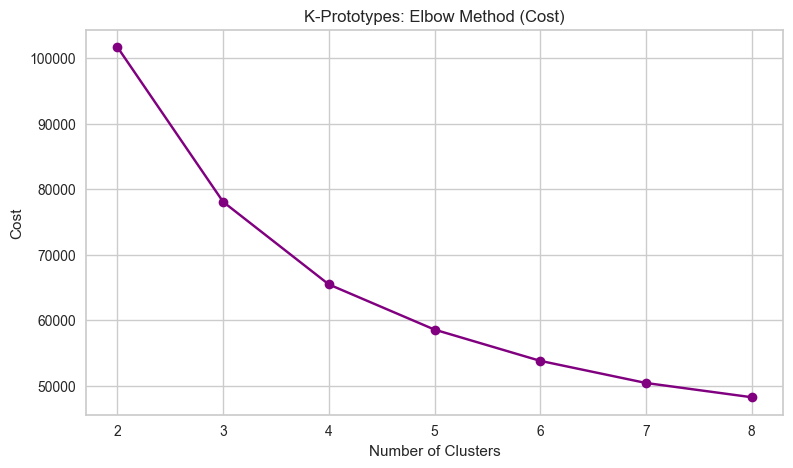


--- Step 3: Fit K-Prototypes with K=4 ---
K-Prototypes clustering completed with K=4
Cluster distribution:
0    1864
1    3251
2    1988
3    9702
Name: count, dtype: int64

--- Step 4: PCA Visualization ---


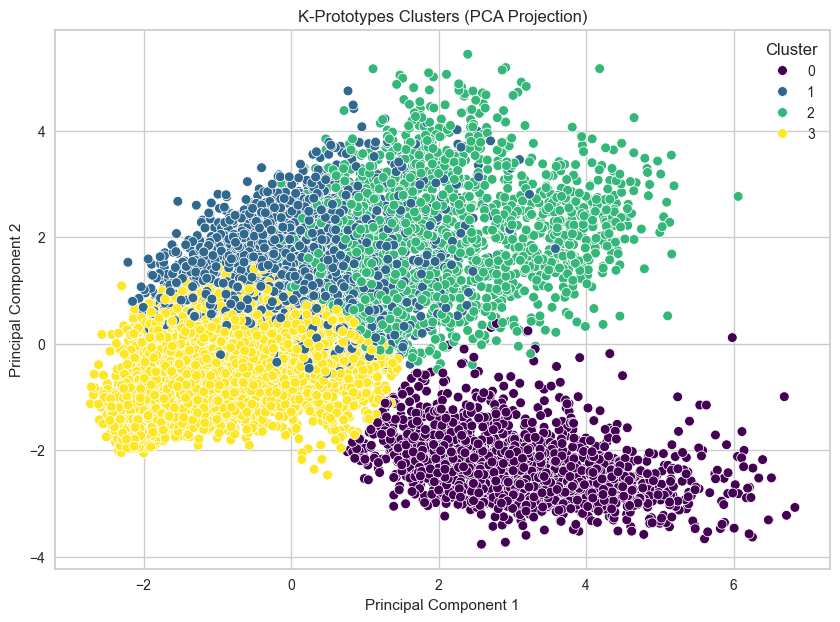


--- Step 5: Cluster Profiles ---


,number_complaints,distinct_stores_visited,percentage_of_products_bought_promotion,Age,Total_Spend,Total_Minors,Share_Tech_Gaming,Share_Fresh_Food,Share_Groceries,Share_Drinks
Cluster_KPrototypes,,,,,,,,,,
0,-0.394,-0.993,-0.356,0.006,-0.129,-0.519,3.995,-0.853,-0.648,0.248
1,0.040,1.554,0.757,0.026,-0.276,-0.113,0.315,0.541,-0.398,0.252
2,0.207,-0.351,0.244,-0.034,-0.473,0.064,0.673,1.100,-1.500,2.618
3,0.109,-0.384,-0.101,0.021,0.506,0.543,-0.133,-0.100,0.324,-0.207


In [8]:
# --- 5.1.2 K-PROTOTYPES CLUSTERING ---
# K-Prototypes handles mixed data (numerical + categorical)
from kmodes.kprototypes import KPrototypes

# 1. Prepare Mixed Data: Combine scaled numerics with original categorical
print("--- Step 1: Prepare Mixed Data ---")

# Get categorical column(s) from original data
categorical_cols = ['customer_gender']  # Add more if needed

# Create mixed dataframe: scaled numerics + original categoricals
df_mixed = df_scaled[metric_features].copy()

# Add categorical features from original 'data' dataframe
for col in categorical_cols:
    if col in data.columns:
        # Align indices
        df_mixed[col] = data.loc[df_scaled.index, col].values

print(f"Mixed data shape: {df_mixed.shape}")
print(f"Numerical features: {len(metric_features)}")
print(f"Categorical features: {categorical_cols}")

# 2. Find Optimal K using Cost Function
print("\n--- Step 2: Elbow Method for K-Prototypes ---")
cat_indices = [df_mixed.columns.get_loc(col) for col in categorical_cols]

costs = []
range_k = range(2, 9)

for k in range_k:
    kproto = KPrototypes(n_clusters=k, init='Cao', random_state=42, n_jobs=-1)
    kproto.fit(df_mixed.values, categorical=cat_indices)
    costs.append(kproto.cost_)
    print(f"K={k}: Cost = {kproto.cost_:.2f}")

plt.figure(figsize=(9, 5))
plt.plot(range_k, costs, marker='o', color='purple')
plt.xlabel("Number of Clusters")
plt.ylabel("Cost")
plt.title("K-Prototypes: Elbow Method (Cost)")
plt.xticks(range_k)
plt.grid(True)
plt.show()

# 3. Fit K-Prototypes with Optimal K
OPTIMAL_K_KPROTO = 4  # <-- Adjust based on elbow plot!
print(f"\n--- Step 3: Fit K-Prototypes with K={OPTIMAL_K_KPROTO} ---")

kproto_final = KPrototypes(n_clusters=OPTIMAL_K_KPROTO, init='Cao', random_state=42, n_jobs=-1)
kproto_labels = kproto_final.fit_predict(df_mixed.values, categorical=cat_indices)

df_scaled['Cluster_KPrototypes'] = kproto_labels

print(f"K-Prototypes clustering completed with K={OPTIMAL_K_KPROTO}")
print(f"Cluster distribution:\n{pd.Series(kproto_labels).value_counts().sort_index()}")

# 4. Visualize Clusters using PCA (on numerical features only)
print("\n--- Step 4: PCA Visualization ---")
plot_clusters_pca(df_scaled[metric_features], kproto_labels, title="K-Prototypes Clusters")

# 5. Cluster Profiling
print("\n--- Step 5: Cluster Profiles ---")
cluster_profiles_kproto = get_mean_bylabel(df_scaled, metric_features, 'Cluster_KPrototypes')
display(cluster_profiles_kproto.style.background_gradient(cmap='RdYlGn', axis=0).format("{:.3f}"))

### 5.1.3 Agglomerative (Hierarchical) Clustering

**Objective:**
Apply Hierarchical Clustering using Ward's method to identify natural groupings based on Euclidean distance.

**Methodology:**
1. **Dendrogram Visualization:** Visualize the hierarchical structure to identify the optimal cut point.
2. **R² Analysis:** Compare different linkage methods (Ward, Complete, Average, Single) using R² metric.
3. **Cluster Assignment:** Fit the model with the optimal number of clusters.
4. **Profile Analysis:** Compare cluster characteristics with other methods.

--- Step 1: Dendrogram (Ward Linkage) ---


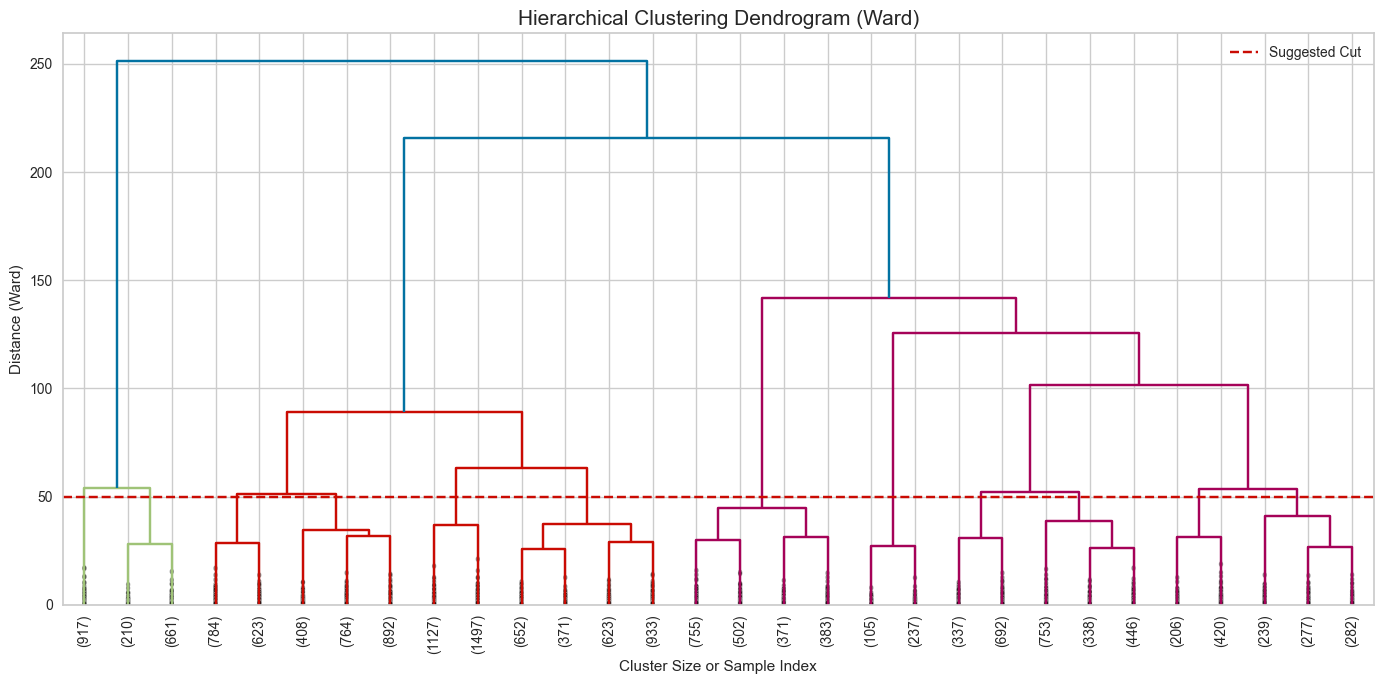


--- Step 2: R² Analysis by Linkage Method ---


/var/folders/fh/9zv17qsx12x8r21nqlmn7bch0000gn/T/ipykernel_31347/3944361754.py:47: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ssw_labels = df_concat.groupby(by='labels').apply(get_ss)
/var/folders/fh/9zv17qsx12x8r21nqlmn7bch0000gn/T/ipykernel_31347/3944361754.py:47: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ssw_labels = df_concat.groupby(by='labels').apply(get_ss)
/var/folders/fh/9zv17qsx12x8r21nqlmn7bch0000gn

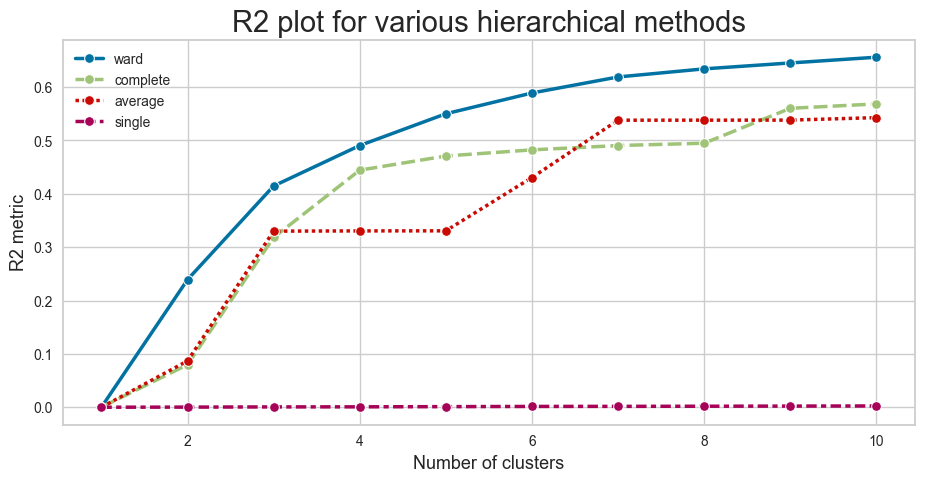


--- Step 3: Fit Agglomerative Clustering with K=4 ---
Hierarchical clustering completed with K=4
Cluster distribution:
Cluster_Hierarchical
0    4332
1    1788
2    8674
3    2011
Name: count, dtype: int64

--- Step 4: PCA Visualization ---


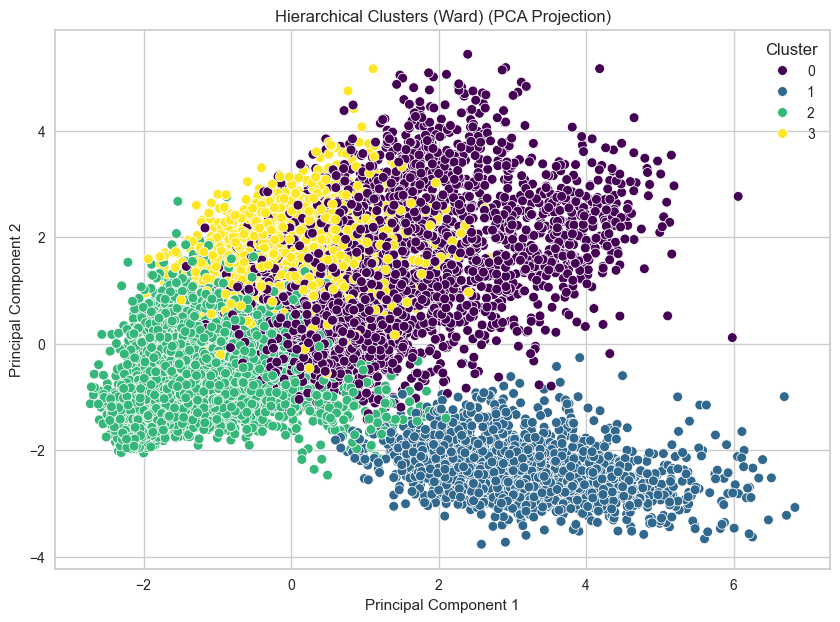


--- Step 5: Cluster Profiles ---


,number_complaints,distinct_stores_visited,percentage_of_products_bought_promotion,Age,Total_Spend,Total_Minors,Share_Tech_Gaming,Share_Fresh_Food,Share_Groceries,Share_Drinks
Cluster_Hierarchical,,,,,,,,,,
0,0.160,-0.322,0.368,0.033,-0.350,0.061,0.504,0.783,-0.904,1.361
1,-0.402,-0.999,-0.353,0.014,-0.121,-0.530,4.070,-0.882,-0.648,0.236
2,0.102,-0.229,-0.164,0.002,0.618,0.617,-0.183,-0.164,0.406,-0.265
3,0.005,1.963,0.878,0.022,-0.394,-0.300,0.326,0.494,-0.387,0.228


In [9]:
# --- 5.1.3 AGGLOMERATIVE (HIERARCHICAL) CLUSTERING ---
from scipy.cluster.hierarchy import dendrogram, linkage

# 1. Dendrogram Visualization
print("--- Step 1: Dendrogram (Ward Linkage) ---")
plt.figure(figsize=(14, 7))
plt.title("Hierarchical Clustering Dendrogram (Ward)", fontsize=15)

# Compute linkage matrix
Z = linkage(df_scaled[metric_features], method='ward')

# Plot dendrogram (truncated for readability)
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=10, show_contracted=True)
plt.xlabel("Cluster Size or Sample Index")
plt.ylabel("Distance (Ward)")
plt.axhline(y=50, color='r', linestyle='--', label='Suggested Cut')  # Adjust cut line
plt.legend()
plt.tight_layout()
plt.show()

# 2. R² Analysis: Compare Linkage Methods
print("\n--- Step 2: R² Analysis by Linkage Method ---")
plot_r2_linkage(df_scaled[metric_features], max_nclus=10)

# 3. Fit Agglomerative Clustering
OPTIMAL_K_HC = 4  # <-- Adjust based on dendrogram and R² plot!
print(f"\n--- Step 3: Fit Agglomerative Clustering with K={OPTIMAL_K_HC} ---")

hc_model = AgglomerativeClustering(n_clusters=OPTIMAL_K_HC, linkage='ward')
df_scaled['Cluster_Hierarchical'] = hc_model.fit_predict(df_scaled[metric_features])

print(f"Hierarchical clustering completed with K={OPTIMAL_K_HC}")
print(f"Cluster distribution:\n{df_scaled['Cluster_Hierarchical'].value_counts().sort_index()}")

# 4. PCA Visualization
print("\n--- Step 4: PCA Visualization ---")
plot_clusters_pca(df_scaled[metric_features], df_scaled['Cluster_Hierarchical'], title="Hierarchical Clusters (Ward)")

# 5. Cluster Profiling
print("\n--- Step 5: Cluster Profiles ---")
cluster_profiles_hc = get_mean_bylabel(df_scaled, metric_features, 'Cluster_Hierarchical')
display(cluster_profiles_hc.style.background_gradient(cmap='RdYlGn', axis=0).format("{:.3f}"))

### 5.1.4 DBSCAN (Density-Based Clustering)

**Objective:**
Apply DBSCAN to identify clusters based on density, which can naturally detect noise points (outliers) and doesn't require specifying the number of clusters upfront.

**Methodology:**
1. **K-Distance Graph:** Determine the optimal `eps` parameter by finding the "elbow" in the k-distance graph.
2. **Parameter Selection:** Choose `eps` and `min_samples` based on the analysis.
3. **Cluster Assignment:** Fit DBSCAN and identify core points, border points, and noise.
4. **Comparison:** Compare density-based clusters with partition-based methods (K-Means, K-Prototypes).

--- Step 1: K-Distance Graph ---
Using MinPts = 20 (2 × 10 features)


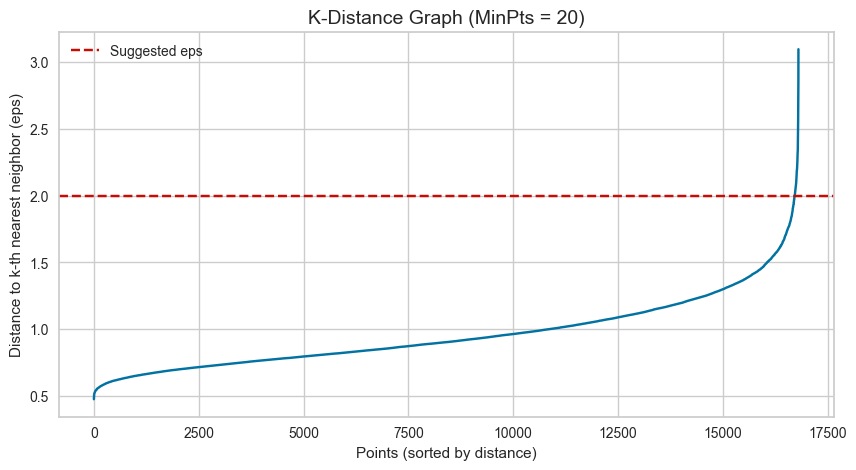


--- Step 2: Fit DBSCAN (eps=2.0, min_samples=20) ---

DBSCAN Results:
  - Number of clusters: 1
  - Noise points (outliers): 3 (0.02%)

Cluster distribution:
-1        3
 0    16802
Name: count, dtype: int64

--- Step 3: PCA Visualization ---


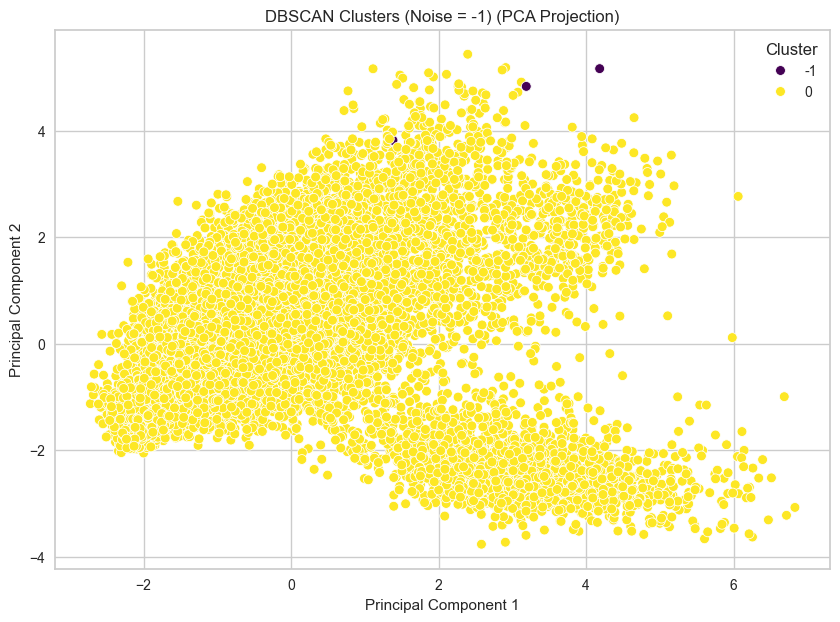


--- Step 4: Cluster Profiles (Excluding Noise) ---


,number_complaints,distinct_stores_visited,percentage_of_products_bought_promotion,Age,Total_Spend,Total_Minors,Share_Tech_Gaming,Share_Fresh_Food,Share_Groceries,Share_Drinks
Cluster_DBSCAN,,,,,,,,,,
0,0.052,-0.073,0.077,0.014,0.169,0.242,0.507,0.082,-0.139,0.266


In [10]:
# --- 5.1.4 DBSCAN (DENSITY-BASED CLUSTERING) ---
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# 1. K-Distance Graph to find optimal eps
print("--- Step 1: K-Distance Graph ---")

# MinPts heuristic: 2 * number of features
min_pts = 2 * len(metric_features)
print(f"Using MinPts = {min_pts} (2 × {len(metric_features)} features)")

# Compute k-distances
nbrs = NearestNeighbors(n_neighbors=min_pts).fit(df_scaled[metric_features])
distances, indices = nbrs.kneighbors(df_scaled[metric_features])
k_distances = np.sort(distances[:, min_pts-1])

plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.title(f'K-Distance Graph (MinPts = {min_pts})', fontsize=14)
plt.xlabel('Points (sorted by distance)')
plt.ylabel('Distance to k-th nearest neighbor (eps)')
plt.axhline(y=2.0, color='r', linestyle='--', label='Suggested eps')  # Adjust based on elbow
plt.grid(True)
plt.legend()
plt.show()

# 2. Fit DBSCAN with chosen parameters
EPS_VALUE = 2.0  # <-- Adjust based on the k-distance graph elbow!
MIN_SAMPLES = min_pts

print(f"\n--- Step 2: Fit DBSCAN (eps={EPS_VALUE}, min_samples={MIN_SAMPLES}) ---")

dbscan = DBSCAN(eps=EPS_VALUE, min_samples=MIN_SAMPLES)
db_labels = dbscan.fit_predict(df_scaled[metric_features])

df_scaled['Cluster_DBSCAN'] = db_labels

# 3. Analyze Results
n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)

print(f"\nDBSCAN Results:")
print(f"  - Number of clusters: {n_clusters}")
print(f"  - Noise points (outliers): {n_noise} ({n_noise/len(db_labels)*100:.2f}%)")
print(f"\nCluster distribution:")
print(pd.Series(db_labels).value_counts().sort_index())

# 4. PCA Visualization (including noise points)
print("\n--- Step 3: PCA Visualization ---")
plot_clusters_pca(df_scaled[metric_features], db_labels, title="DBSCAN Clusters (Noise = -1)")

# 5. Cluster Profiling (excluding noise for meaningful profiles)
print("\n--- Step 4: Cluster Profiles (Excluding Noise) ---")
if n_clusters > 0:
    df_no_noise = df_scaled[df_scaled['Cluster_DBSCAN'] != -1].copy()
    if len(df_no_noise) > 0:
        cluster_profiles_dbscan = get_mean_bylabel(df_no_noise, metric_features, 'Cluster_DBSCAN')
        display(cluster_profiles_dbscan.style.background_gradient(cmap='RdYlGn', axis=0).format("{:.3f}"))
    else:
        print("All points classified as noise!")
else:
    print("No clusters found. Try adjusting eps or min_samples.")

---
## 6. Conclusions & Cluster Comparison

**Objective:**
Compare the results of all clustering algorithms applied and provide actionable insights about customer segments.

**Comparison Criteria:**
1. **Cluster Stability:** Are the clusters consistent across methods?
2. **Silhouette Quality:** Which method produces the most cohesive clusters?
3. **Business Interpretability:** Which segmentation provides actionable marketing insights?
4. **Noise Handling:** How do density-based methods differ from partition-based ones?

6.1 SILHOUETTE SCORE COMPARISON

Silhouette Score Ranking (Higher = Better):


,Algorithm,Silhouette Score
1,K-Prototypes,0.3109
0,K-Means,0.3098
2,Hierarchical,0.2787



6.2 CLUSTER DISTRIBUTION COMPARISON


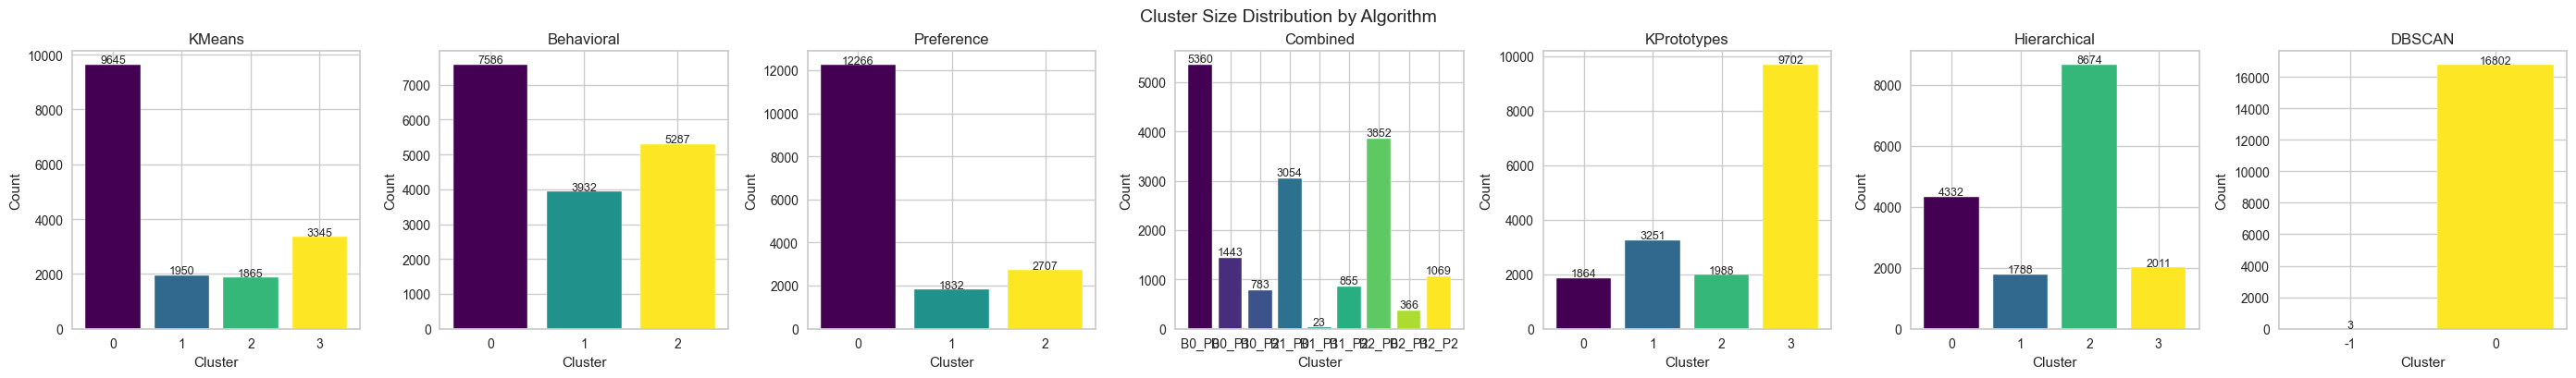


6.3 CLUSTER AGREEMENT (K-Means vs Hierarchical)

Cross-tabulation (rows=K-Means, columns=Hierarchical):


Cluster_Hierarchical,0,1,2,3,Total
Cluster_KMeans,,,,,
0,1577,6,8051,11,9645
1,1935,0,3,12,1950
2,42,1782,41,0,1865
3,778,0,579,1988,3345
Total,4332,1788,8674,2011,16805



6.4 FINAL SUMMARY

ANALYSIS SUMMARY:
-----------------
• Dataset: 16805 customers after preprocessing
• Features used: 10 behavioral/demographic variables
• Algorithms applied: 7 clustering methods

KEY FINDINGS:
• Best Silhouette Score: K-Prototypes (0.3109)
• Recommended for production: Consider K-Prototypes for customer segmentation

NEXT STEPS:
1. Validate cluster interpretability with business stakeholders
2. Apply cluster labels to original customer data for targeting
3. Monitor cluster stability over time with new data



In [11]:
# --- 6. CONCLUSIONS & CLUSTER COMPARISON ---

# 1. Silhouette Score Comparison
print("=" * 60)
print("6.1 SILHOUETTE SCORE COMPARISON")
print("=" * 60)

from sklearn.metrics import silhouette_score

# Calculate silhouette scores for each method
silhouette_results = {}

# K-Means
if 'Cluster_KMeans' in df_scaled.columns:
    sil_kmeans = silhouette_score(df_scaled[metric_features], df_scaled['Cluster_KMeans'])
    silhouette_results['K-Means'] = sil_kmeans

# K-Prototypes
if 'Cluster_KPrototypes' in df_scaled.columns:
    sil_kproto = silhouette_score(df_scaled[metric_features], df_scaled['Cluster_KPrototypes'])
    silhouette_results['K-Prototypes'] = sil_kproto

# Hierarchical
if 'Cluster_Hierarchical' in df_scaled.columns:
    sil_hc = silhouette_score(df_scaled[metric_features], df_scaled['Cluster_Hierarchical'])
    silhouette_results['Hierarchical'] = sil_hc

# DBSCAN (excluding noise)
if 'Cluster_DBSCAN' in df_scaled.columns:
    df_no_noise = df_scaled[df_scaled['Cluster_DBSCAN'] != -1]
    if len(df_no_noise) > 0 and len(df_no_noise['Cluster_DBSCAN'].unique()) > 1:
        sil_dbscan = silhouette_score(df_no_noise[metric_features], df_no_noise['Cluster_DBSCAN'])
        silhouette_results['DBSCAN'] = sil_dbscan

# Display comparison
sil_df = pd.DataFrame(list(silhouette_results.items()), columns=['Algorithm', 'Silhouette Score'])
sil_df = sil_df.sort_values('Silhouette Score', ascending=False)
print("\nSilhouette Score Ranking (Higher = Better):")
display(sil_df.style.background_gradient(cmap='Greens', subset=['Silhouette Score']).format({'Silhouette Score': '{:.4f}'}))

# 2. Cluster Distribution Comparison
print("\n" + "=" * 60)
print("6.2 CLUSTER DISTRIBUTION COMPARISON")
print("=" * 60)

cluster_cols = [col for col in df_scaled.columns if col.startswith('Cluster_')]
fig, axes = plt.subplots(1, len(cluster_cols), figsize=(4*len(cluster_cols), 4))

if len(cluster_cols) == 1:
    axes = [axes]

for i, col in enumerate(cluster_cols):
    counts = df_scaled[col].value_counts().sort_index()
    axes[i].bar(counts.index.astype(str), counts.values, color=plt.cm.viridis(np.linspace(0, 1, len(counts))))
    axes[i].set_title(col.replace('Cluster_', ''))
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel('Count')
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 50, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.suptitle("Cluster Size Distribution by Algorithm", y=1.02, fontsize=14)
plt.show()

# 3. Cross-tabulation: Agreement between methods
print("\n" + "=" * 60)
print("6.3 CLUSTER AGREEMENT (K-Means vs Hierarchical)")
print("=" * 60)

if 'Cluster_KMeans' in df_scaled.columns and 'Cluster_Hierarchical' in df_scaled.columns:
    cross_tab = pd.crosstab(df_scaled['Cluster_KMeans'], df_scaled['Cluster_Hierarchical'], 
                            margins=True, margins_name='Total')
    print("\nCross-tabulation (rows=K-Means, columns=Hierarchical):")
    display(cross_tab.style.background_gradient(cmap='Blues'))

# 4. Summary Statistics
print("\n" + "=" * 60)
print("6.4 FINAL SUMMARY")
print("=" * 60)

print(f"""
ANALYSIS SUMMARY:
-----------------
• Dataset: {len(df_scaled)} customers after preprocessing
• Features used: {len(metric_features)} behavioral/demographic variables
• Algorithms applied: {len(cluster_cols)} clustering methods

KEY FINDINGS:
• Best Silhouette Score: {sil_df.iloc[0]['Algorithm']} ({sil_df.iloc[0]['Silhouette Score']:.4f})
• Recommended for production: Consider {sil_df.iloc[0]['Algorithm']} for customer segmentation

NEXT STEPS:
1. Validate cluster interpretability with business stakeholders
2. Apply cluster labels to original customer data for targeting
3. Monitor cluster stability over time with new data
""")

6.5 DETAILED CLUSTER PROFILES (Best Method)

Detailed analysis using: K-Prototypes


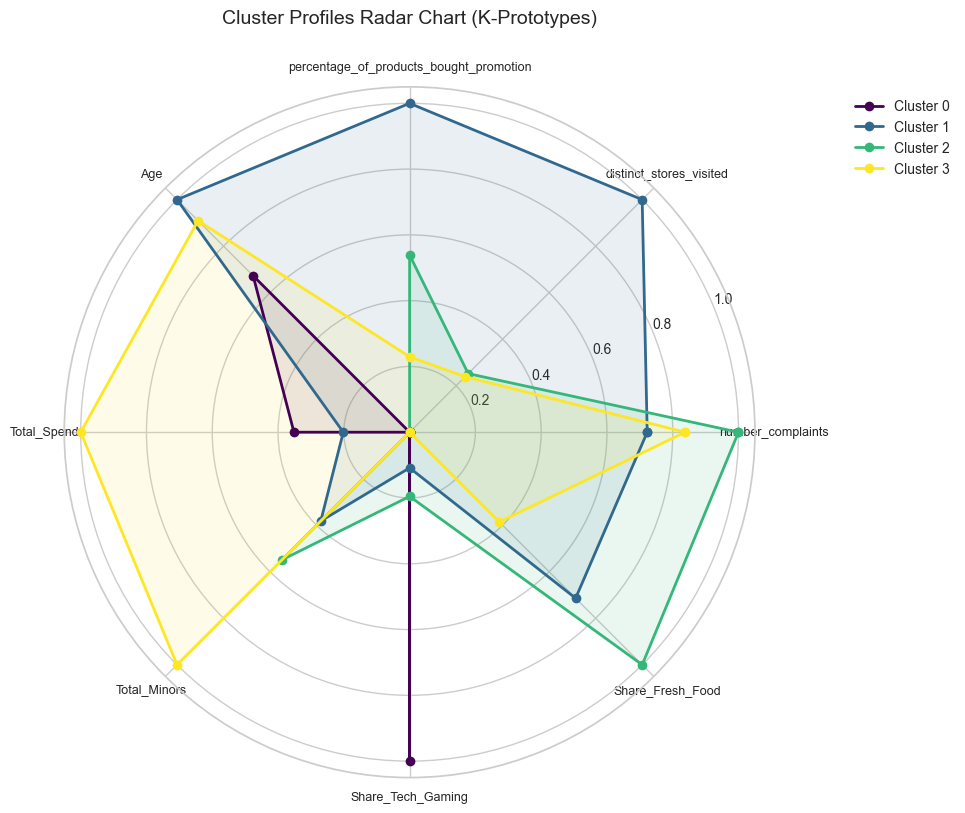


Cluster Profile Heatmap (Normalized):


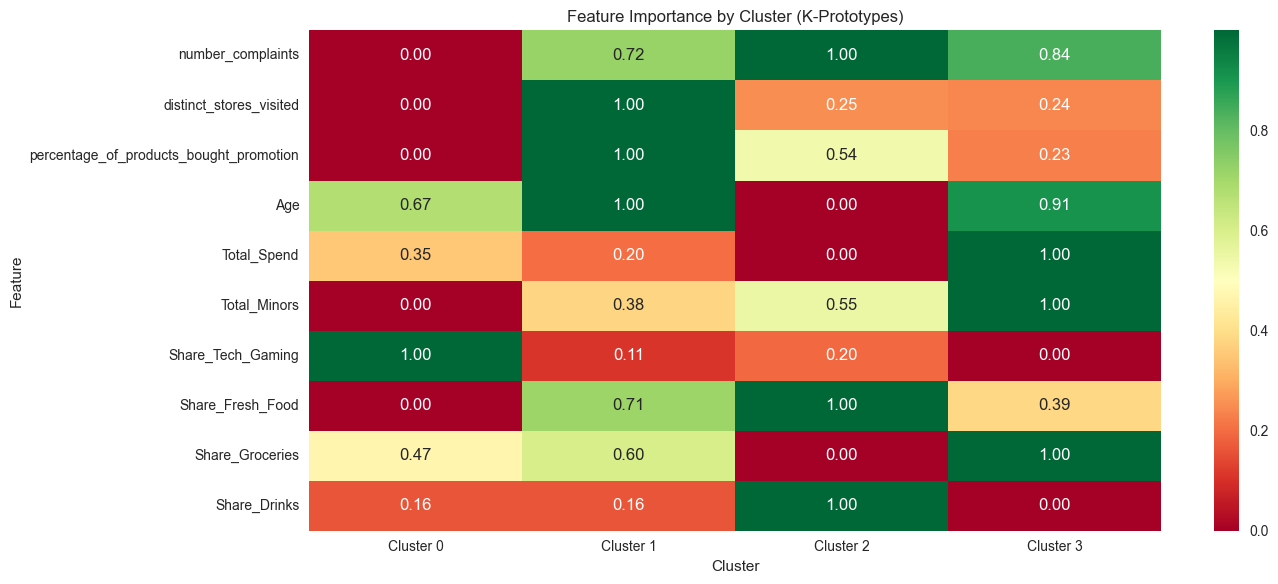


--- Saving Results ---
Cluster labels saved to 'data' dataframe under 'Final_Cluster' column
Total customers segmented: 16805


In [12]:
# --- 6.5 CLUSTER PROFILING: BEST METHOD ---
print("=" * 60)
print("6.5 DETAILED CLUSTER PROFILES (Best Method)")
print("=" * 60)

# Use the best performing method for detailed profiling
best_method = sil_df.iloc[0]['Algorithm']
best_cluster_col = f'Cluster_{best_method.replace("-", "")}'

# Handle naming variations
if best_cluster_col not in df_scaled.columns:
    best_cluster_col = [c for c in cluster_cols if best_method.replace("-", "").lower() in c.lower()][0]

print(f"\nDetailed analysis using: {best_method}")

# Radar Chart for Cluster Profiles
from math import pi

# Prepare data for radar chart
profile_data = df_scaled.groupby(best_cluster_col)[metric_features].mean()
profile_data_norm = (profile_data - profile_data.min()) / (profile_data.max() - profile_data.min() + 1e-6)

# Select top features for visualization (max 8 for readability)
top_features = metric_features[:8] if len(metric_features) > 8 else metric_features

# Create radar chart
num_clusters = len(profile_data)
angles = [n / float(len(top_features)) * 2 * pi for n in range(len(top_features))]
angles += angles[:1]  # Complete the circle

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
colors = plt.cm.viridis(np.linspace(0, 1, num_clusters))

for idx, (cluster_id, row) in enumerate(profile_data_norm[top_features].iterrows()):
    values = row.values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=f'Cluster {cluster_id}', color=colors[idx])
    ax.fill(angles, values, alpha=0.1, color=colors[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(top_features, size=9)
ax.set_title(f"Cluster Profiles Radar Chart ({best_method})", size=14, y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
plt.tight_layout()
plt.show()

# Heatmap of Cluster Profiles
print("\nCluster Profile Heatmap (Normalized):")
plt.figure(figsize=(14, 6))
sns.heatmap(profile_data_norm.T, annot=True, fmt=".2f", cmap='RdYlGn', 
            xticklabels=[f'Cluster {i}' for i in profile_data.index],
            yticklabels=metric_features)
plt.title(f"Feature Importance by Cluster ({best_method})")
plt.xlabel("Cluster")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Save cluster labels to original data
print("\n--- Saving Results ---")
data.loc[df_scaled.index, 'Final_Cluster'] = df_scaled[best_cluster_col]
print(f"Cluster labels saved to 'data' dataframe under 'Final_Cluster' column")
print(f"Total customers segmented: {data['Final_Cluster'].notna().sum()}")